# 🧠 Complete Pipeline: sEEG Speech Decoding — From Raw NWB to Results

**Paper:** NeuroTalk Architectural Transfer for sEEG Mel-Spectrogram Reconstruction  
**Dataset:** SingleWordProductionDutch-iBIDS (Verwoert et al., 2022)

### Pipeline Overview:
1. **Extract features** from raw NWB files (High-Gamma + 80-band Mel)
2. **Split** into train/val/test per subject
3. **Train** Baseline + Hybrid + NeuroTalk + Ablation
4. **Evaluate** with PCC, MSE, statistical tests
5. **Vocoder** HiFi-GAN → PESQ/STOI

### Bugs Fixed from Original:
- ❌ Mel was 23 bands → ✅ Now 80 bands (HiFi-GAN compatible)
- ❌ Context stacking → shape (T, C×9) → ✅ Now (C, T) directly
- ❌ One file per subject → ✅ Now per-trial files + manifest
- ❌ Auto-transpose → ✅ Explicit validation
- ❌ Global PCC → ✅ Per-sample PCC then average

## Step 0: Imports & Configuration

In [1]:
import os, sys, copy, random, json, time, warnings
import numpy as np
import pandas as pd
from pathlib import Path
from collections import defaultdict

# Signal processing
import scipy.signal
import scipy.fftpack
from scipy.signal import sosfiltfilt, butter, hilbert, iirnotch, iirfilter

# Audio
import librosa

# NWB
from pynwb import NWBHDF5IO

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

warnings.filterwarnings("ignore")
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
print(f"PyTorch: {torch.__version__}")
print("✅ All imports OK")

Device: cpu
PyTorch: 2.2.2+cpu
✅ All imports OK


In [ ]:
# ═══════════════════════════════════════════════════════════════
# ⚙️ CONFIGURATION
# ═══════════════════════════════════════════════════════════════
# Paths are read from environment variables so this notebook runs
# unmodified on any machine (see README.md "Configuration"). If the
# environment variables are not set, they fall back to ./data and
# ./extracted_data relative to this notebook's working directory.
import os

# 📁 Path to your local copy of the SingleWordProductionDutch-iBIDS dataset
#    (download from https://osf.io/nrgx6 -- see README.md "Data")
DATA_ROOT = os.environ.get("SEEG_DATA_ROOT", "./data/SingleWordProductionDutch-iBIDS")

# 📁 Where to save extracted features
OUTPUT_DIR = os.environ.get("SEEG_OUTPUT_DIR", "./extracted_data")

# Subject mapping
SUBJECTS_BIDS = [f"sub-{i:02d}" for i in range(1, 11)]
SUBJECTS_NAME = [f"SUB{i}" for i in range(1, 11)]
SUB_MAP = dict(zip(SUBJECTS_BIDS, SUBJECTS_NAME))

# Signal processing
SEEG_SRATE     = 1024
HG_LOW, HG_HIGH = 70, 170
NOTCH_FREQS    = [100, 150]
BUTTER_ORDER   = 4
WIN_SEC        = 0.05    # 50ms window
SHIFT_SEC      = 0.01    # 10ms frameshift

# Mel spectrogram (80 bands -- dimension-compatible with HiFi-GAN,
# though this pipeline reconstructs audio with Griffin-Lim; see README)
AUDIO_SR       = 16000
MEL_BINS       = 80
MEL_FMIN       = 0
MEL_FMAX       = 8000
N_FFT          = 1024

# Fixed output dimensions (must match model)
T_EEG_FIXED    = 300    # ~3 sec at 10ms shift
T_MEL_FIXED    = 300    # ~3 sec at 10ms shift
TARGET_CH      = 127

# Training
BATCH_SIZE     = 4
PATIENCE       = 8
WEIGHT_DECAY   = 1e-4
SEED           = 42

# Splits
TRAIN_RATIO, VAL_RATIO, TEST_RATIO = 0.80, 0.10, 0.10

os.makedirs(OUTPUT_DIR, exist_ok=True)
print("✅ Configuration set")
print(f"   Data root: {DATA_ROOT}")
print(f"   Output:    {OUTPUT_DIR}")
if not os.path.exists(DATA_ROOT):
    print(f"   ⚠️  DATA_ROOT does not exist yet -- set the SEEG_DATA_ROOT "
          f"environment variable or edit DATA_ROOT above before running "
          f"Step 1 (Feature Extraction).")


## Step 1: Feature Extraction from Raw NWB

### 1.1 High-Gamma Envelope Extraction
Pipeline: Raw sEEG → Detrend → Bandpass (70-170Hz) → Notch (100,150Hz) → Hilbert → Envelope → Windowed Mean

In [3]:
def extract_high_gamma(data, sr):
    """
    Extract high-gamma envelope from raw sEEG.
    
    Input:  data — (samples, channels) raw sEEG signal
    Output: feat — (channels, frames) high-gamma envelope
    
    Pipeline:
        1. Linear detrend
        2. Bandpass 70-170 Hz (4th-order Butterworth, zero-phase)
        3. Notch 100 Hz, 150 Hz (line noise harmonics)
        4. Hilbert transform → analytic signal envelope
        5. Windowed mean pooling (50ms window, 10ms shift)
    """
    n_samples, n_channels = data.shape
    data = data.astype(np.float64)
    
    # 1. Linear detrend
    data = scipy.signal.detrend(data, axis=0)
    
    # 2. Bandpass 70-170 Hz
    nyq = sr / 2.0
    sos = iirfilter(BUTTER_ORDER, [HG_LOW/nyq, HG_HIGH/nyq], 
                    btype='bandpass', output='sos')
    data = sosfiltfilt(sos, data, axis=0)
    
    # 3. Notch filters (line noise harmonics)
    for freq in NOTCH_FREQS:
        sos_notch = iirfilter(BUTTER_ORDER, 
                              [(freq-2)/nyq, (freq+2)/nyq],
                              btype='bandstop', output='sos')
        data = sosfiltfilt(sos_notch, data, axis=0)
    
    # 4. Hilbert → envelope
    # Use fast length for speed
    fast_len = scipy.fftpack.next_fast_len(n_samples)
    analytic = scipy.signal.hilbert(data, N=fast_len, axis=0)[:n_samples]
    envelope = np.abs(analytic)
    
    # 5. Windowed mean pooling
    win_samples = int(WIN_SEC * sr)
    shift_samples = int(SHIFT_SEC * sr)
    n_frames = int(np.floor((n_samples - win_samples) / shift_samples)) + 1
    
    feat = np.zeros((n_channels, n_frames), dtype=np.float32)
    for f in range(n_frames):
        start = f * shift_samples
        stop = start + win_samples
        feat[:, f] = envelope[start:stop, :].mean(axis=0)
    
    return feat  # (channels, frames) — NO context stacking!

print("✅ extract_high_gamma defined")
print("   NOTE: Returns (C, T) — no context stacking")
print("   NOTE: This fixes the original bug where shape was (T, C×9)")

✅ extract_high_gamma defined
   NOTE: Returns (C, T) — no context stacking
   NOTE: This fixes the original bug where shape was (T, C×9)


### 1.2 Mel-Spectrogram Extraction (80 bands)

In [4]:
def extract_mel_spectrogram(audio, sr):
    """
    Extract 80-band log-mel spectrogram.
    
    Input:  audio — (samples,) waveform at any sample rate
    Output: mel   — (80, frames) log-mel spectrogram
    
    Compatible with HiFi-GAN V1 vocoder.
    
    NOTE: Original used 23 bands with custom MelFilterBank.
          Now using 80 bands with librosa (standard).
    """
    # Resample to 16kHz if needed
    if sr != AUDIO_SR:
        audio = librosa.resample(audio.astype(np.float32), 
                                  orig_sr=sr, target_sr=AUDIO_SR)
        sr = AUDIO_SR
    
    hop_length = int(SHIFT_SEC * sr)     # 160 samples
    win_length = int(WIN_SEC * sr)       # 800 samples
    
    mel = librosa.feature.melspectrogram(
        y=audio.astype(np.float32), sr=sr,
        n_fft=N_FFT, hop_length=hop_length, win_length=win_length,
        window='hann', n_mels=MEL_BINS, 
        fmin=MEL_FMIN, fmax=MEL_FMAX,
        power=2.0, center=True, pad_mode='reflect')
    
    # Log-mel
    log_mel = np.log(np.maximum(mel, 1e-10)).astype(np.float32)
    return log_mel  # (80, frames)

print("✅ extract_mel_spectrogram defined")
print("   NOTE: 80 bands (was 23 in original — FIXED)")
print("   NOTE: Uses librosa (was custom MelFilterBank — FIXED)")

✅ extract_mel_spectrogram defined
   NOTE: 80 bands (was 23 in original — FIXED)
   NOTE: Uses librosa (was custom MelFilterBank — FIXED)


### 1.3 Helper Functions

In [5]:
def pad_or_crop(x, T_fixed):
    """Center-pad or center-crop to fixed length. x: (D, T)"""
    D, T = x.shape
    if T == T_fixed: return x
    if T > T_fixed:
        start = (T - T_fixed) // 2
        return x[:, start:start + T_fixed]
    out = np.zeros((D, T_fixed), dtype=x.dtype)
    start = (T_fixed - T) // 2
    out[:, start:start + T] = x
    return out

def read_nwb(nwb_path):
    """Read sEEG + audio from NWB file."""
    io = NWBHDF5IO(str(nwb_path), 'r')
    nwb = io.read()
    
    seeg = nwb.acquisition['iEEG'].data[:]        # (samples, channels)
    seeg_sr = 1024
    audio = nwb.acquisition['Audio'].data[:]       # (samples,)
    audio_sr = 48000
    words = np.array(nwb.acquisition['Stimulus'].data[:], dtype=str)
    
    io.close()
    return seeg, seeg_sr, audio.flatten(), audio_sr, words

def read_events(events_path):
    """Read events TSV file."""
    df = pd.read_csv(events_path, sep='\t')
    events = []
    for _, row in df.iterrows():
        dur = float(row.get('duration', 0))
        if dur > 0.05:
            events.append({
                'onset': float(row['onset']),
                'duration': dur,
                'value': str(row.get('value', row.get('trial_type', '')))
            })
    return events

print("✅ Helper functions defined")

✅ Helper functions defined


### 1.4 🚀 Run Feature Extraction

In [6]:
os.makedirs(OUTPUT_DIR, exist_ok=True)
all_records = []

for sub_bids in SUBJECTS_BIDS:
    sub_name = SUB_MAP[sub_bids]
    print(f"\n{'='*60}")
    print(f"▶ {sub_bids} → {sub_name}")
    print(f"{'='*60}")
    
    sub_dir = Path(DATA_ROOT) / sub_bids / "ieeg"
    out_dir = Path(OUTPUT_DIR) / sub_name
    out_dir.mkdir(parents=True, exist_ok=True)
    
    nwb_path = sub_dir / f"{sub_bids}_task-wordProduction_ieeg.nwb"
    events_path = sub_dir / f"{sub_bids}_task-wordProduction_events.tsv"
    
    # Read data
    seeg, seeg_sr, audio, audio_sr, words = read_nwb(nwb_path)
    print(f"  sEEG: {seeg.shape} @ {seeg_sr}Hz, Channels: {seeg.shape[1]}")
    
    # Read events — FILTER ONLY WORDS (not fixation!)
    events_df = pd.read_csv(events_path, sep='\t')
    word_events = events_df[events_df['trial_type'] == 'word'].reset_index(drop=True)
    print(f"  Word trials: {len(word_events)} (filtered from {len(events_df)} total events)")
    
    for trial_idx, (_, ev) in enumerate(word_events.iterrows()):
        onset = ev['onset']
        duration = ev['duration']
        word = str(ev['value'])
        
        # Segment: 500ms pre + word + 500ms post
        pre, post = 0.5, 0.5
        s_start = max(0, int((onset - pre) * seeg_sr))
        s_end = min(seeg.shape[0], int((onset + duration + post) * seeg_sr))
        a_start = max(0, int((onset - pre) * audio_sr))
        a_end = min(len(audio), int((onset + duration + post) * audio_sr))
        
        seeg_seg = seeg[s_start:s_end, :]
        audio_seg = audio[a_start:a_end]
        
        # Extract features
        eeg_feat = extract_high_gamma(seeg_seg, seeg_sr)
        mel_feat = extract_mel_spectrogram(audio_seg, audio_sr)
        
        # Align to fixed sizes
        eeg_feat = pad_or_crop(eeg_feat, T_EEG_FIXED)
        mel_feat = pad_or_crop(mel_feat, T_MEL_FIXED)
        
        # Save audio 16kHz for vocoder
        audio_16k = librosa.resample(audio_seg.astype(np.float32),
                                      orig_sr=audio_sr, target_sr=AUDIO_SR)
        
        # Save
        eeg_path = out_dir / f"trial_{trial_idx:03d}_eeg.npy"
        mel_path = out_dir / f"trial_{trial_idx:03d}_mel.npy"
        aud_path = out_dir / f"trial_{trial_idx:03d}_audio.npy"
        np.save(eeg_path, eeg_feat)
        np.save(mel_path, mel_feat)
        np.save(aud_path, audio_16k)
        
        all_records.append({
            'subject': sub_name,
            'trial_idx': trial_idx,
            'word': word,
            'eeg_path': str(eeg_path),
            'mel_path': str(mel_path),
            'audio_path': str(aud_path),
            'n_channels': seeg_seg.shape[1],
        })
    
    print(f"  ✅ {len([r for r in all_records if r['subject']==sub_name])} word trials saved")

print(f"\n🎉 Total: {len(all_records)} trials (should be ~1000 = 10 subjects × 100 words)")


▶ sub-01 → SUB1
  sEEG: (307511, 127) @ 1024Hz, Channels: 127
  Word trials: 100 (filtered from 199 total events)
  ✅ 100 word trials saved

▶ sub-02 → SUB2
  sEEG: (307516, 127) @ 1024Hz, Channels: 127
  Word trials: 100 (filtered from 199 total events)
  ✅ 100 word trials saved

▶ sub-03 → SUB3
  sEEG: (307523, 127) @ 1024Hz, Channels: 127
  Word trials: 100 (filtered from 199 total events)
  ✅ 100 word trials saved

▶ sub-04 → SUB4
  sEEG: (307521, 115) @ 1024Hz, Channels: 115
  Word trials: 100 (filtered from 199 total events)
  ✅ 100 word trials saved

▶ sub-05 → SUB5
  sEEG: (307497, 60) @ 1024Hz, Channels: 60
  Word trials: 100 (filtered from 199 total events)
  ✅ 100 word trials saved

▶ sub-06 → SUB6
  sEEG: (307594, 127) @ 1024Hz, Channels: 127
  Word trials: 100 (filtered from 199 total events)
  ✅ 100 word trials saved

▶ sub-07 → SUB7
  sEEG: (307576, 127) @ 1024Hz, Channels: 127
  Word trials: 100 (filtered from 199 total events)
  ✅ 100 word trials saved

▶ sub-08 → SUB

### 1.5 Create Train/Val/Test Splits + Manifest

In [7]:
# Create DataFrame
df = pd.DataFrame(all_records)

# Assign stratified splits per subject
np.random.seed(SEED)
splits = []
for sub in sorted(df['subject'].unique()):
    sub_df = df[df['subject'] == sub]
    n = len(sub_df)
    indices = np.random.permutation(n)
    n_train = int(n * TRAIN_RATIO)
    n_val = int(n * VAL_RATIO)
    for i, idx in enumerate(indices):
        if i < n_train: splits.append("train")
        elif i < n_train + n_val: splits.append("val")
        else: splits.append("test")

df['split'] = splits

# Save manifest
manifest_path = os.path.join(OUTPUT_DIR, "manifest_pairs.csv")
df.to_csv(manifest_path, index=False)

# Summary
print("\n" + "="*60)
print("📊 DATASET SUMMARY")
print("="*60)
for sub in SUBJECTS_NAME:
    sub_df = df[df['subject'] == sub]
    n_tr = len(sub_df[sub_df['split']=='train'])
    n_va = len(sub_df[sub_df['split']=='val'])
    n_te = len(sub_df[sub_df['split']=='test'])
    print(f"  {sub}: {len(sub_df)} trials ({n_tr}/{n_va}/{n_te}), {sub_df['n_channels'].iloc[0]} ch")

print(f"\nTotal: {len(df)} trials")
print(f"  Train: {len(df[df['split']=='train'])}")
print(f"  Val:   {len(df[df['split']=='val'])}")
print(f"  Test:  {len(df[df['split']=='test'])}")
print(f"\n📄 Manifest: {manifest_path}")


📊 DATASET SUMMARY
  SUB1: 100 trials (80/10/10), 127 ch
  SUB2: 100 trials (80/10/10), 127 ch
  SUB3: 100 trials (80/10/10), 127 ch
  SUB4: 100 trials (80/10/10), 115 ch
  SUB5: 100 trials (80/10/10), 60 ch
  SUB6: 100 trials (80/10/10), 127 ch
  SUB7: 100 trials (80/10/10), 127 ch
  SUB8: 100 trials (80/10/10), 54 ch
  SUB9: 100 trials (80/10/10), 117 ch
  SUB10: 100 trials (80/10/10), 122 ch

Total: 1000 trials
  Train: 800
  Val:   100
  Test:  100

📄 Manifest: C:\Users\PC\Desktop\courses\Conferences\Sevile\test\extracted_data\manifest_pairs.csv


### 1.6 ✅ Verify Extracted Features

In [8]:
print("\n" + "="*60)
print("🔍 VERIFICATION")
print("="*60)

issues = 0
for sub in SUBJECTS_NAME:
    sub_df = df[df['subject'] == sub]
    if len(sub_df) == 0: continue
    row = sub_df.iloc[0]
    eeg = np.load(row['eeg_path'])
    mel = np.load(row['mel_path'])
    
    errors = []
    if eeg.shape[1] != T_EEG_FIXED: errors.append(f"EEG time={eeg.shape[1]}")
    if mel.shape != (MEL_BINS, T_MEL_FIXED): errors.append(f"Mel={mel.shape}")
    if np.any(np.isnan(eeg)): errors.append("EEG has NaN")
    if np.any(np.isnan(mel)): errors.append("Mel has NaN")
    if eeg.min() < 0: errors.append("EEG negative (not envelope?)")
    
    if errors:
        print(f"  ⚠ {sub}: {', '.join(errors)}")
        issues += 1
    else:
        print(f"  ✅ {sub}: EEG={eeg.shape}, Mel={mel.shape}, range=[{eeg.min():.3f},{eeg.max():.3f}]")

if issues == 0:
    print("\n✅ ALL CHECKS PASSED — Ready for training!")
else:
    print(f"\n⚠ {issues} ISSUES — Fix before continuing!")


🔍 VERIFICATION
  ✅ SUB1: EEG=(127, 300), Mel=(80, 300), range=[0.000,150.109]
  ✅ SUB2: EEG=(127, 300), Mel=(80, 300), range=[0.000,14.097]
  ✅ SUB3: EEG=(127, 300), Mel=(80, 300), range=[0.000,29.567]
  ✅ SUB4: EEG=(115, 300), Mel=(80, 300), range=[0.000,73.673]
  ✅ SUB5: EEG=(60, 300), Mel=(80, 300), range=[0.000,27.249]
  ✅ SUB6: EEG=(127, 300), Mel=(80, 300), range=[0.000,15.137]
  ✅ SUB7: EEG=(127, 300), Mel=(80, 300), range=[0.000,35.738]
  ✅ SUB8: EEG=(54, 300), Mel=(80, 300), range=[0.000,9.435]
  ✅ SUB9: EEG=(117, 300), Mel=(80, 300), range=[0.000,233.815]
  ✅ SUB10: EEG=(122, 300), Mel=(80, 300), range=[0.000,63.215]

✅ ALL CHECKS PASSED — Ready for training!


---\n## Step 2: Dataset & DataLoaders

In [9]:
# ═══════════════════════════════════════════════════════════════
# DATASET CLASS
# ═══════════════════════════════════════════════════════════════
MANIFEST_CSV = os.path.join(OUTPUT_DIR, "manifest_pairs.csv")

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def compute_eeg_stats(manifest_csv, subjects):
    """Per-channel mean/std from TRAINING split only."""
    df = pd.read_csv(manifest_csv)
    stats = {}
    for sub in subjects:
        sub_df = df[(df['subject'] == sub) & (df['split'] == 'train')]
        if len(sub_df) == 0: continue
        all_sum, all_sumsq, total_t, expected_C = None, None, 0, None
        for _, row in sub_df.iterrows():
            x = np.load(row['eeg_path']).astype(np.float64)  # (C, T)
            C, T = x.shape
            if expected_C is None: expected_C = C
            assert C == expected_C, f"{sub}: channel mismatch {C} vs {expected_C}"
            if all_sum is None:
                all_sum = x.sum(axis=1)
                all_sumsq = (x**2).sum(axis=1)
            else:
                all_sum += x.sum(axis=1)
                all_sumsq += (x**2).sum(axis=1)
            total_t += T
        mean = (all_sum / total_t).astype(np.float32)
        std = np.sqrt(np.maximum(all_sumsq/total_t - mean.astype(np.float64)**2, 1e-8)).astype(np.float32)
        stats[sub] = (mean, std)
        print(f"  {sub}: {expected_C}ch, mean=[{mean.min():.3f},{mean.max():.3f}]")
    return stats

class SpeechDataset(Dataset):
    def __init__(self, manifest_csv, split, subjects, eeg_stats, use_mask=True):
        df = pd.read_csv(manifest_csv)
        self.df = df[(df['split']==split) & (df['subject'].isin(subjects))].reset_index(drop=True)
        self.split = split
        self.subjects = list(subjects)
        self.sub2idx = {s:i for i,s in enumerate(self.subjects)}
        self.eeg_stats = eeg_stats
        self.use_mask = use_mask

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        subj = row['subject']
        eeg = np.load(row['eeg_path']).astype(np.float32)  # (C, T)
        mel = np.load(row['mel_path']).astype(np.float32)   # (80, 259)
        
        # Z-score normalize
        C = eeg.shape[0]
        mean, std = self.eeg_stats[subj]
        eeg = (eeg - mean[:C, None]) / (std[:C, None] + 1e-8)
        
        # Pad channels
        eeg_pad = np.zeros((TARGET_CH, T_EEG_FIXED), dtype=np.float32)
        eeg_pad[:C, :] = eeg
        
        # Mask
        mask = np.zeros((TARGET_CH, 1), dtype=np.float32)
        mask[:C if self.use_mask else TARGET_CH, 0] = 1.0
        
        sid = self.sub2idx[subj]
        return (torch.from_numpy(eeg_pad), torch.from_numpy(mel),
                torch.from_numpy(mask), torch.tensor(sid, dtype=torch.long))

# Build loaders
print("\n▶ Computing EEG statistics...")
eeg_stats = compute_eeg_stats(MANIFEST_CSV, SUBJECTS_NAME)

set_seed(SEED)
train_set = SpeechDataset(MANIFEST_CSV, "train", SUBJECTS_NAME, eeg_stats)
val_set   = SpeechDataset(MANIFEST_CSV, "val",   SUBJECTS_NAME, eeg_stats)
test_set  = SpeechDataset(MANIFEST_CSV, "test",  SUBJECTS_NAME, eeg_stats)

sub_counts = train_set.df['subject'].value_counts().to_dict()
weights = [1.0/sub_counts[s] for s in train_set.df['subject'].tolist()]
sampler = WeightedRandomSampler(weights, len(weights), replacement=True)

train_loader = DataLoader(train_set, BATCH_SIZE, sampler=sampler, num_workers=0)
val_loader   = DataLoader(val_set, BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_set, BATCH_SIZE, shuffle=False, num_workers=0)

print(f"\n✅ Data ready: Train={len(train_set)}, Val={len(val_set)}, Test={len(test_set)}")


▶ Computing EEG statistics...
  SUB1: 127ch, mean=[0.842,28.048]
  SUB2: 127ch, mean=[0.771,7.325]
  SUB3: 127ch, mean=[0.933,7.491]
  SUB4: 115ch, mean=[1.205,44.625]
  SUB5: 60ch, mean=[0.765,4.498]
  SUB6: 127ch, mean=[0.967,4.395]
  SUB7: 127ch, mean=[0.711,11.450]
  SUB8: 54ch, mean=[1.088,3.536]
  SUB9: 117ch, mean=[0.752,8.008]
  SUB10: 122ch, mean=[0.730,14.357]

✅ Data ready: Train=800, Val=100, Test=100


---\n## Step 3: Model Architectures

In [10]:
# ═══════════════════════════════════════════════════════════════
# MR-ResBlock (NeuroTalk core component)
# ═══════════════════════════════════════════════════════════════
class MRResBlock(nn.Module):
    def __init__(self, ch, kernels=(3,5,7), norm='bn', dropout=0.1):
        super().__init__()
        self.branches = nn.ModuleList()
        for k in kernels:
            self.branches.append(nn.Sequential(
                nn.Conv1d(ch, ch, k, padding=k//2),
                nn.BatchNorm1d(ch) if norm=='bn' else nn.GroupNorm(min(32,ch), ch),
                nn.LeakyReLU(0.2)))
        self.merge = nn.Sequential(
            nn.Conv1d(ch*len(kernels), ch, 1),
            nn.BatchNorm1d(ch) if norm=='bn' else nn.GroupNorm(min(32,ch), ch),
            nn.LeakyReLU(0.2))
        self.dropout = nn.Dropout(dropout)
    def forward(self, x):
        return x + self.dropout(self.merge(torch.cat([b(x) for b in self.branches], dim=1)))

# ═══════════════════════════════════════════════════════════════
# BASELINE: CNN-BiLSTM
# ═══════════════════════════════════════════════════════════════
class BaselineModel(nn.Module):
    def __init__(self, n_sub=10, emb=32, hid=256):
        super().__init__()
        self.sub_embed = nn.Embedding(n_sub, emb)
        self.encoder = nn.Sequential(
            nn.Conv1d(TARGET_CH,128,7,padding=3), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(128,256,7,padding=3), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(256,256,7,padding=3), nn.ReLU(), nn.MaxPool1d(2))
        self.pool = nn.AdaptiveAvgPool1d(T_MEL_FIXED)
        self.lstm = nn.LSTM(256+emb, hid, 1, batch_first=True, bidirectional=True)
        self.proj = nn.Linear(hid*2, MEL_BINS)
    def forward(self, x, mask, sid):
        z = self.pool(self.encoder(x*mask)).permute(0,2,1)
        e = self.sub_embed(sid).unsqueeze(1).expand(-1,z.size(1),-1)
        return self.proj(self.lstm(torch.cat([z,e],dim=-1))[0]).permute(0,2,1)

# ═══════════════════════════════════════════════════════════════
# HYBRID: CNN-BiLSTM + 5 MR-ResBlocks (Architecture Transfer)
# ═══════════════════════════════════════════════════════════════
class HybridModel(nn.Module):
    def __init__(self, n_sub=10, emb=32, hid=256, kernels=(3,5,7), norm='bn'):
        super().__init__()
        self.sub_embed = nn.Embedding(n_sub, emb)
        self.conv1 = nn.Sequential(nn.Conv1d(TARGET_CH,128,7,padding=3), nn.ReLU(), nn.MaxPool1d(2))
        self.conv2 = nn.Sequential(nn.Conv1d(128,256,7,padding=3), nn.ReLU(), nn.MaxPool1d(2))
        self.conv3 = nn.Sequential(nn.Conv1d(256,256,7,padding=3), nn.ReLU(), nn.MaxPool1d(2))
        self.mr1 = MRResBlock(128, kernels, norm)
        self.mr2 = MRResBlock(256, kernels, norm)
        self.mr3 = MRResBlock(256, kernels, norm)
        self.mr_pre = MRResBlock(256, kernels, norm)
        self.mr_post = MRResBlock(256, kernels, norm)
        self.pool = nn.AdaptiveAvgPool1d(T_MEL_FIXED)
        self.lstm = nn.LSTM(256+emb, hid, 1, batch_first=True, bidirectional=True)
        self.post_proj = nn.Linear(hid*2, 256)
        self.final_proj = nn.Linear(256, MEL_BINS)
    
    def forward(self, x, mask, sid):
        z = self.mr1(self.conv1(x*mask))
        z = self.mr2(self.conv2(z))
        z = self.mr_pre(self.mr3(self.conv3(z)))
        z = self.pool(z).permute(0,2,1)
        e = self.sub_embed(sid).unsqueeze(1).expand(-1,z.size(1),-1)
        z, _ = self.lstm(torch.cat([z,e], dim=-1))
        z = self.post_proj(z).permute(0,2,1)
        z = self.mr_post(z).permute(0,2,1)
        return self.final_proj(z).permute(0,2,1)
    
    def transfer_from_baseline(self, sd):
        mapping = {"encoder.0.weight":"conv1.0.weight","encoder.0.bias":"conv1.0.bias",
                   "encoder.3.weight":"conv2.0.weight","encoder.3.bias":"conv2.0.bias",
                   "encoder.6.weight":"conv3.0.weight","encoder.6.bias":"conv3.0.bias"}
        for k in sd:
            if 'lstm' in k or 'sub_embed' in k: mapping[k] = k
        my_sd = self.state_dict()
        t = 0
        for s,d in mapping.items():
            if s in sd and d in my_sd and sd[s].shape == my_sd[d].shape:
                my_sd[d] = sd[s]; t += 1
        self.load_state_dict(my_sd)
        print(f"  Transferred {t}/{len(mapping)} tensors")

# Print params
for name, cls in [("Baseline", BaselineModel), ("Hybrid", HybridModel)]:
    m = cls()
    p = sum(x.numel() for x in m.parameters())
    print(f"  {name}: {p:,} params")
    del m
print("✅ Models defined")

  Baseline: 1,962,128 params
  Hybrid: 7,100,304 params
✅ Models defined


In [11]:
# ============================================================
# Capacity-Matched Control: نفس بنية MR-ResBlock لكن بـkernel واحد (k=5)
# بدل {3,5,7} — لعزل أثر "تعدد المقاييس" عن "زيادة السعة الحسابية"
# ============================================================
class SingleKernelResBlock(nn.Module):
    def __init__(self, ch, norm='bn', dropout=0.1):
        super().__init__()
        kernels = (5, 5, 5)
        self.branches = nn.ModuleList()
        for k in kernels:
            self.branches.append(nn.Sequential(
                nn.Conv1d(ch, ch, k, padding=k//2),
                nn.BatchNorm1d(ch) if norm == 'bn' else nn.GroupNorm(min(32, ch), ch),
                nn.LeakyReLU(0.2)))
        self.merge = nn.Sequential(
            nn.Conv1d(ch*len(kernels), ch, 1),
            nn.BatchNorm1d(ch) if norm == 'bn' else nn.GroupNorm(min(32, ch), ch),
            nn.LeakyReLU(0.2))
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        return x + self.dropout(self.merge(torch.cat([b(x) for b in self.branches], dim=1)))


class HybridModelSingleKernel(nn.Module):
    def __init__(self, n_sub=10, emb=32, hid=256, norm='bn'):
        super().__init__()
        self.sub_embed = nn.Embedding(n_sub, emb)
        self.conv1 = nn.Sequential(nn.Conv1d(TARGET_CH,128,7,padding=3), nn.ReLU(), nn.MaxPool1d(2))
        self.conv2 = nn.Sequential(nn.Conv1d(128,256,7,padding=3), nn.ReLU(), nn.MaxPool1d(2))
        self.conv3 = nn.Sequential(nn.Conv1d(256,256,7,padding=3), nn.ReLU(), nn.MaxPool1d(2))
        self.mr1 = SingleKernelResBlock(128, norm)
        self.mr2 = SingleKernelResBlock(256, norm)
        self.mr3 = SingleKernelResBlock(256, norm)
        self.mr_pre = SingleKernelResBlock(256, norm)
        self.mr_post = SingleKernelResBlock(256, norm)
        self.pool = nn.AdaptiveAvgPool1d(T_MEL_FIXED)
        self.lstm = nn.LSTM(256+emb, hid, 1, batch_first=True, bidirectional=True)
        self.post_proj = nn.Linear(hid*2, 256)
        self.final_proj = nn.Linear(256, MEL_BINS)

    def forward(self, x, mask, sid):
        z = self.mr1(self.conv1(x*mask))
        z = self.mr2(self.conv2(z))
        z = self.mr_pre(self.mr3(self.conv3(z)))
        z = self.pool(z).permute(0,2,1)
        e = self.sub_embed(sid).unsqueeze(1).expand(-1,z.size(1),-1)
        z, _ = self.lstm(torch.cat([z,e], dim=-1))
        z = self.post_proj(z).permute(0,2,1)
        z = self.mr_post(z).permute(0,2,1)
        return self.final_proj(z).permute(0,2,1)

# تحقق سريع من عدد البارامترات (يجب أن يطابق 7,100,304 تمامًا)
_m = HybridModelSingleKernel(n_sub=10)
_p = sum(x.numel() for x in _m.parameters())
print(f"Capacity-Matched params: {_p:,}  (Full Hybrid: 7,100,304, الفرق: {_p-7100304:,})")
del _m
print("✅ HybridModelSingleKernel defined and verified")

Capacity-Matched params: 7,100,304  (Full Hybrid: 7,100,304, الفرق: 0)
✅ HybridModelSingleKernel defined and verified


---\n## Step 4: Training Functions

In [12]:
# ═══════════════════════════════════════════════════════════════
# TRAINING UTILITIES
# ═══════════════════════════════════════════════════════════════
def pearson_pcc(a, b):
    a = a.astype(np.float64).ravel(); b = b.astype(np.float64).ravel()
    a -= a.mean(); b -= b.mean()
    return float((a*b).sum() / (np.sqrt((a*a).sum())*np.sqrt((b*b).sum()) + 1e-8))

criterion = nn.MSELoss()

def run_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total, n = 0.0, 0
    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for xb, yb, mask, sid in loader:
            xb,yb,mask,sid = xb.to(device),yb.to(device),mask.to(device),sid.to(device)
            pred = model(xb, mask, sid)
            loss = criterion(pred, yb)
            if is_train:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            total += loss.item()*xb.size(0); n += xb.size(0)
    return total/max(n,1)

def train_model(model, opt, epochs, label):
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, 'min', 0.5, patience=2)
    best_val, best_sd, pat = float('inf'), None, 0
    print(f"\n{'='*60}\n  TRAINING: {label}\n{'='*60}")
    for ep in range(1, epochs+1):
        tr = run_epoch(model, train_loader, opt)
        va = run_epoch(model, val_loader)
        sched.step(va)
        if ep%5==0 or ep==1: print(f"  Ep {ep:3d} | Train {tr:.4f} | Val {va:.4f}")
        if va < best_val:
            best_val, pat = va, 0
            best_sd = copy.deepcopy(model.state_dict())
        else:
            pat += 1
            if pat >= PATIENCE:
                print(f"  Early stop ep {ep}"); break
    model.load_state_dict(best_sd)
    print(f"  ✅ Best Val = {best_val:.4f}")
    return model

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    per_sub = defaultdict(lambda: {'pcc':[],'mse':[]})
    for xb,yb,mask,sid in loader:
        xb,yb,mask,sid = xb.to(device),yb.to(device),mask.to(device),sid.to(device)
        pred = model(xb,mask,sid)
        for i in range(xb.size(0)):
            p,t = pred[i].cpu().numpy(), yb[i].cpu().numpy()
            s = SUBJECTS_NAME[sid[i].item()]
            per_sub[s]['pcc'].append(pearson_pcc(p,t))
            per_sub[s]['mse'].append(float(((p-t)**2).mean()))
    # Per-subject averages
    results = {}
    all_pcc = []
    for s in SUBJECTS_NAME:
        if s in per_sub:
            results[s] = {'pcc': np.mean(per_sub[s]['pcc']), 'mse': np.mean(per_sub[s]['mse']),
                          'n': len(per_sub[s]['pcc'])}
            all_pcc.extend(per_sub[s]['pcc'])
    results['overall'] = {'pcc': np.mean(all_pcc), 'mse': np.mean([r['mse'] for r in results.values() if 'n' in r])}
    return results

def print_results(label, res):
    print(f"\n{'─'*50}\n  {label}: PCC={res['overall']['pcc']:.4f}  MSE={res['overall']['mse']:.4f}\n{'─'*50}")
    for s in SUBJECTS_NAME:
        if s in res: print(f"    {s}: PCC={res[s]['pcc']:.4f}  MSE={res[s]['mse']:.4f}")

print("✅ Training functions defined")

✅ Training functions defined


---\n## Step 5: 🚀 Run ALL Experiments

### 5.1 Experiment 1: Baseline CNN-BiLSTM

In [13]:
set_seed(SEED)
baseline = BaselineModel(n_sub=10).to(device)
opt_b = torch.optim.Adam(baseline.parameters(), lr=1e-4, weight_decay=WEIGHT_DECAY)
baseline = train_model(baseline, opt_b, 60, "BASELINE CNN-BiLSTM")
baseline_sd = copy.deepcopy(baseline.state_dict())
torch.save(baseline_sd, os.path.join(OUTPUT_DIR, "baseline.pt"))
res_baseline = evaluate(baseline, test_loader)
print_results("Baseline", res_baseline)


  TRAINING: BASELINE CNN-BiLSTM
  Ep   1 | Train 122.5601 | Val 37.9907
  Ep   5 | Train 12.2632 | Val 11.5399
  Ep  10 | Train 7.9204 | Val 11.1568
  Ep  15 | Train 6.2523 | Val 8.9781
  Ep  20 | Train 5.7009 | Val 8.6348
  Ep  25 | Train 4.8789 | Val 8.6962
  Ep  30 | Train 4.3548 | Val 8.4920
  Ep  35 | Train 4.1744 | Val 8.3459
  Ep  40 | Train 4.0048 | Val 8.3312
  Ep  45 | Train 3.7301 | Val 8.4010
  Early stop ep 46
  ✅ Best Val = 8.3018

──────────────────────────────────────────────────
  Baseline: PCC=0.6642  MSE=15.2052
──────────────────────────────────────────────────
    SUB1: PCC=0.6254  MSE=10.6809
    SUB2: PCC=0.5082  MSE=15.9672
    SUB3: PCC=0.8090  MSE=10.3475
    SUB4: PCC=0.7919  MSE=7.7916
    SUB5: PCC=0.4537  MSE=19.4253
    SUB6: PCC=0.8614  MSE=4.1446
    SUB7: PCC=0.6960  MSE=10.1710
    SUB8: PCC=0.7109  MSE=8.8987
    SUB9: PCC=0.7363  MSE=7.1789
    SUB10: PCC=0.4494  MSE=57.4464


### 5.2 Experiment 2: Hybrid — Architecture Transfer (Progressive Fine-tuning)

In [14]:
set_seed(SEED)
hybrid = HybridModel(n_sub=10).to(device)
hybrid.transfer_from_baseline(baseline_sd)

# Differential LR
transferred_p = [p for n,p in hybrid.named_parameters() if not any(k in n for k in ['mr','post_proj','final_proj'])]
new_p = [p for n,p in hybrid.named_parameters() if any(k in n for k in ['mr','post_proj','final_proj'])]
opt_h = torch.optim.Adam([
    {'params': transferred_p, 'lr': 5e-6},
    {'params': new_p, 'lr': 5e-5},
], weight_decay=WEIGHT_DECAY)

hybrid = train_model(hybrid, opt_h, 60, "HYBRID — Architecture Transfer")
torch.save(hybrid.state_dict(), os.path.join(OUTPUT_DIR, "hybrid.pt"))
res_hybrid = evaluate(hybrid, test_loader)
print_results("Hybrid", res_hybrid)

  Transferred 15/15 tensors

  TRAINING: HYBRID — Architecture Transfer
  Ep   1 | Train 120.3436 | Val 15.5628
  Ep   5 | Train 4.3374 | Val 9.7463
  Ep  10 | Train 3.5697 | Val 9.1555
  Ep  15 | Train 3.2606 | Val 9.6398
  Ep  20 | Train 3.0540 | Val 8.6453
  Ep  25 | Train 2.8574 | Val 8.4965
  Ep  30 | Train 2.8034 | Val 8.3269
  Early stop ep 31
  ✅ Best Val = 8.2059

──────────────────────────────────────────────────
  Hybrid: PCC=0.7269  MSE=9.9250
──────────────────────────────────────────────────
    SUB1: PCC=0.6889  MSE=9.6602
    SUB2: PCC=0.5274  MSE=14.8822
    SUB3: PCC=0.7594  MSE=10.3276
    SUB4: PCC=0.7378  MSE=9.9184
    SUB5: PCC=0.5387  MSE=17.6435
    SUB6: PCC=0.8742  MSE=3.9164
    SUB7: PCC=0.8240  MSE=8.0710
    SUB8: PCC=0.7288  MSE=8.8140
    SUB9: PCC=0.7873  MSE=6.0618
    SUB10: PCC=0.8021  MSE=9.9547


### 5.3 Experiment 3: Hybrid from Scratch — NO Progressive Fine-tuning (R1.7)

In [15]:
set_seed(SEED)
scratch = HybridModel(n_sub=10).to(device)
# NO transfer — train everything from random init
opt_s = torch.optim.Adam(scratch.parameters(), lr=1e-4, weight_decay=WEIGHT_DECAY)
scratch = train_model(scratch, opt_s, 120, "HYBRID FROM SCRATCH (no transfer)")
res_scratch = evaluate(scratch, test_loader)
print_results("Scratch", res_scratch)


  TRAINING: HYBRID FROM SCRATCH (no transfer)
  Ep   1 | Train 71.3596 | Val 18.0140
  Ep   5 | Train 6.2096 | Val 9.4895
  Ep  10 | Train 4.1126 | Val 7.5475
  Ep  15 | Train 3.1794 | Val 7.8278
  Ep  20 | Train 2.7927 | Val 7.3901
  Ep  25 | Train 2.3625 | Val 7.3581
  Ep  30 | Train 2.2223 | Val 7.3180
  Early stop ep 30
  ✅ Best Val = 7.2973

──────────────────────────────────────────────────
  Scratch: PCC=0.7851  MSE=8.2188
──────────────────────────────────────────────────
    SUB1: PCC=0.7099  MSE=7.8332
    SUB2: PCC=0.6758  MSE=11.3828
    SUB3: PCC=0.8433  MSE=8.1559
    SUB4: PCC=0.8004  MSE=8.1119
    SUB5: PCC=0.7132  MSE=12.8750
    SUB6: PCC=0.8557  MSE=4.4406
    SUB7: PCC=0.8772  MSE=4.8047
    SUB8: PCC=0.7486  MSE=8.3138
    SUB9: PCC=0.8298  MSE=5.5132
    SUB10: PCC=0.7967  MSE=10.7568


### 5.4 Experiment 4: Fine-tuned Baseline Control (R1.8)

In [16]:
set_seed(SEED)
ft_base = BaselineModel(n_sub=10).to(device)
ft_base.load_state_dict(baseline_sd)
opt_ft = torch.optim.Adam(ft_base.parameters(), lr=5e-6, weight_decay=WEIGHT_DECAY)
ft_base = train_model(ft_base, opt_ft, 60, "FINE-TUNED BASELINE CONTROL")
res_ft = evaluate(ft_base, test_loader)
print_results("FT-Baseline", res_ft)


  TRAINING: FINE-TUNED BASELINE CONTROL
  Ep   1 | Train 3.9813 | Val 8.3778
  Ep   5 | Train 4.1549 | Val 8.3021
  Ep  10 | Train 3.6975 | Val 8.3344
  Ep  15 | Train 3.5653 | Val 8.2872
  Ep  20 | Train 3.8355 | Val 8.3053
  Early stop ep 24
  ✅ Best Val = 8.2827

──────────────────────────────────────────────────
  FT-Baseline: PCC=0.6730  MSE=14.7314
──────────────────────────────────────────────────
    SUB1: PCC=0.6315  MSE=10.5733
    SUB2: PCC=0.5168  MSE=15.7878
    SUB3: PCC=0.8079  MSE=10.2293
    SUB4: PCC=0.7867  MSE=8.0065
    SUB5: PCC=0.4858  MSE=18.7829
    SUB6: PCC=0.8601  MSE=4.1775
    SUB7: PCC=0.7335  MSE=9.8070
    SUB8: PCC=0.7124  MSE=8.9930
    SUB9: PCC=0.7186  MSE=7.6460
    SUB10: PCC=0.4764  MSE=53.3109


---\n## Step 6: Ablation Study

In [17]:
ablation_results = {}

# 6.1 Conv-Only (3 blocks) — FROM SCRATCH (نفس بروتوكول Scratch: lr=1e-4, 120 epoch)
set_seed(SEED)
class ConvOnlyModel(HybridModel):
    def __init__(self, **kw):
        super().__init__(**kw)
        self.proj_direct = nn.Linear(512, MEL_BINS)
    def forward(self, x, mask, sid):
        z = self.mr1(self.conv1(x*mask))
        z = self.mr2(self.conv2(z))
        z = self.mr3(self.conv3(z))
        z = self.pool(z).permute(0,2,1)
        e = self.sub_embed(sid).unsqueeze(1).expand(-1,z.size(1),-1)
        z, _ = self.lstm(torch.cat([z,e], dim=-1))
        return self.proj_direct(z).permute(0,2,1)

m = ConvOnlyModel(n_sub=10).to(device)
opt = torch.optim.Adam(m.parameters(), lr=1e-4, weight_decay=WEIGHT_DECAY)
m = train_model(m, opt, 120, "ABLATION-SCRATCH: Conv-Only (3 blocks)")
ablation_results['conv_only'] = evaluate(m, test_loader)
print_results("Conv-Only", ablation_results['conv_only'])

# 6.2 No Pre-LSTM (4 blocks) — FROM SCRATCH
set_seed(SEED)
class NoPreModel(HybridModel):
    def forward(self, x, mask, sid):
        z = self.mr1(self.conv1(x*mask))
        z = self.mr2(self.conv2(z))
        z = self.mr3(self.conv3(z))
        z = self.pool(z).permute(0,2,1)
        e = self.sub_embed(sid).unsqueeze(1).expand(-1,z.size(1),-1)
        z, _ = self.lstm(torch.cat([z,e], dim=-1))
        z = self.post_proj(z).permute(0,2,1)
        z = self.mr_post(z).permute(0,2,1)
        return self.final_proj(z).permute(0,2,1)

m = NoPreModel(n_sub=10).to(device)
opt = torch.optim.Adam(m.parameters(), lr=1e-4, weight_decay=WEIGHT_DECAY)
m = train_model(m, opt, 120, "ABLATION-SCRATCH: No Pre-LSTM (4 blocks)")
ablation_results['no_pre'] = evaluate(m, test_loader)
print_results("No Pre-LSTM", ablation_results['no_pre'])

# 6.3 No Post-LSTM (4 blocks) — FROM SCRATCH
set_seed(SEED)
class NoPostModel(HybridModel):
    def __init__(self, **kw):
        super().__init__(**kw)
        self.proj_direct = nn.Linear(512, MEL_BINS)
    def forward(self, x, mask, sid):
        z = self.mr_pre(self.mr3(self.conv3(self.mr2(self.conv2(self.mr1(self.conv1(x*mask)))))))
        z = self.pool(z).permute(0,2,1)
        e = self.sub_embed(sid).unsqueeze(1).expand(-1,z.size(1),-1)
        z, _ = self.lstm(torch.cat([z,e], dim=-1))
        return self.proj_direct(z).permute(0,2,1)

m = NoPostModel(n_sub=10).to(device)
opt = torch.optim.Adam(m.parameters(), lr=1e-4, weight_decay=WEIGHT_DECAY)
m = train_model(m, opt, 120, "ABLATION-SCRATCH: No Post-LSTM (4 blocks)")
ablation_results['no_post'] = evaluate(m, test_loader)
print_results("No Post-LSTM", ablation_results['no_post'])

# 6.4 Capacity-Matched Control (5 blocks, single-kernel k=5) — FROM SCRATCH
set_seed(SEED)
m = HybridModelSingleKernel(n_sub=10).to(device)
opt = torch.optim.Adam(m.parameters(), lr=1e-4, weight_decay=WEIGHT_DECAY)
m = train_model(m, opt, 120, "ABLATION-SCRATCH: Capacity-Matched (single-kernel k=5)")
ablation_results['capacity_matched'] = evaluate(m, test_loader)
print_results("Capacity-Matched", ablation_results['capacity_matched'])

print("\n✅ Ablation (corrected + capacity-matched) complete")


  TRAINING: ABLATION-SCRATCH: Conv-Only (3 blocks)
  Ep   1 | Train 122.3395 | Val 40.3373
  Ep   5 | Train 8.7431 | Val 9.8542
  Ep  10 | Train 5.8219 | Val 9.5127
  Ep  15 | Train 3.9879 | Val 8.1897
  Ep  20 | Train 3.5285 | Val 8.2835
  Ep  25 | Train 3.0904 | Val 8.4011
  Early stop ep 25
  ✅ Best Val = 8.1843

──────────────────────────────────────────────────
  Conv-Only: PCC=0.7379  MSE=9.6785
──────────────────────────────────────────────────
    SUB1: PCC=0.6834  MSE=9.8651
    SUB2: PCC=0.6359  MSE=13.3766
    SUB3: PCC=0.7791  MSE=11.1134
    SUB4: PCC=0.7967  MSE=7.9073
    SUB5: PCC=0.5663  MSE=16.1569
    SUB6: PCC=0.8490  MSE=5.2450
    SUB7: PCC=0.8317  MSE=7.4264
    SUB8: PCC=0.6861  MSE=8.1231
    SUB9: PCC=0.8235  MSE=5.1668
    SUB10: PCC=0.7267  MSE=12.4047

  TRAINING: ABLATION-SCRATCH: No Pre-LSTM (4 blocks)
  Ep   1 | Train 72.5660 | Val 14.4919
  Ep   5 | Train 6.5959 | Val 9.4192
  Ep  10 | Train 4.8276 | Val 8.0628
  Ep  15 | Train 3.7110 | Val 8.1766
  Ep

---\n## Step 7: 📊 Final Summary + Statistical Tests

In [18]:
from scipy import stats as sp_stats

print("\n" + "="*70)
print("📊 FINAL SUMMARY TABLE")
print("="*70)

all_exp = {
    'Baseline': res_baseline,
    'Hybrid (Transfer)': res_hybrid,
    'Hybrid (Scratch)': res_scratch,
    'FT-Baseline': res_ft,
    'Conv-Only (3)': ablation_results.get('conv_only',{}),
    'No Pre-LSTM (4)': ablation_results.get('no_pre',{}),
    'No Post-LSTM (4)': ablation_results.get('no_post',{}),
}

print(f"\n{'Model':<25} {'PCC':>8} {'MSE':>8}")
print("-"*45)
for name, res in all_exp.items():
    if 'overall' in res:
        print(f"{name:<25} {res['overall']['pcc']:>8.4f} {res['overall']['mse']:>8.4f}")

# Statistical comparison: Baseline vs Hybrid
b_pccs = [res_baseline[s]['pcc'] for s in SUBJECTS_NAME if s in res_baseline]
h_pccs = [res_hybrid[s]['pcc'] for s in SUBJECTS_NAME if s in res_hybrid]
deltas = [h-b for h,b in zip(h_pccs, b_pccs)]

mean_d = np.mean(deltas)
std_d = np.std(deltas, ddof=1)
n = len(deltas)

try:
    W, p_w = sp_stats.wilcoxon(deltas, alternative='greater')
except: W, p_w = float('nan'), float('nan')
t_stat, t_p = sp_stats.ttest_rel(h_pccs, b_pccs)
d_cohen = mean_d / (std_d + 1e-8)
se = std_d / np.sqrt(n)
t_crit = sp_stats.t.ppf(0.975, n-1)

print(f"\n📊 Baseline vs Hybrid:")
print(f"   ΔPCC = {mean_d:.4f} ± {std_d:.4f}")
print(f"   95% CI: [{mean_d-t_crit*se:.4f}, {mean_d+t_crit*se:.4f}]")
print(f"   Wilcoxon W={W:.0f}, p={p_w:.4f}")
print(f"   Cohen's d = {d_cohen:.2f}")
print(f"   All positive: {all(d>0 for d in deltas)}")

# Save
with open(os.path.join(OUTPUT_DIR, 'results.json'), 'w') as f:
    json.dump({k: v.get('overall',{}) for k,v in all_exp.items()}, f, indent=2)
print(f"\n✅ Results saved to {OUTPUT_DIR}/results.json")


📊 FINAL SUMMARY TABLE

Model                          PCC      MSE
---------------------------------------------
Baseline                    0.6642  15.2052
Hybrid (Transfer)           0.7269   9.9250
Hybrid (Scratch)            0.7851   8.2188
FT-Baseline                 0.6730  14.7314
Conv-Only (3)               0.7379   9.6785
No Pre-LSTM (4)             0.7757   8.2764
No Post-LSTM (4)            0.7805   8.4886

📊 Baseline vs Hybrid:
   ΔPCC = 0.0626 ± 0.1162
   95% CI: [-0.0205, 0.1458]
   Wilcoxon W=45, p=0.0420
   Cohen's d = 0.54
   All positive: False

✅ Results saved to C:\Users\PC\Desktop\courses\Conferences\Sevile\test\extracted_data/results.json


---\n## Step 8: Mel-Spectrogram Visualization

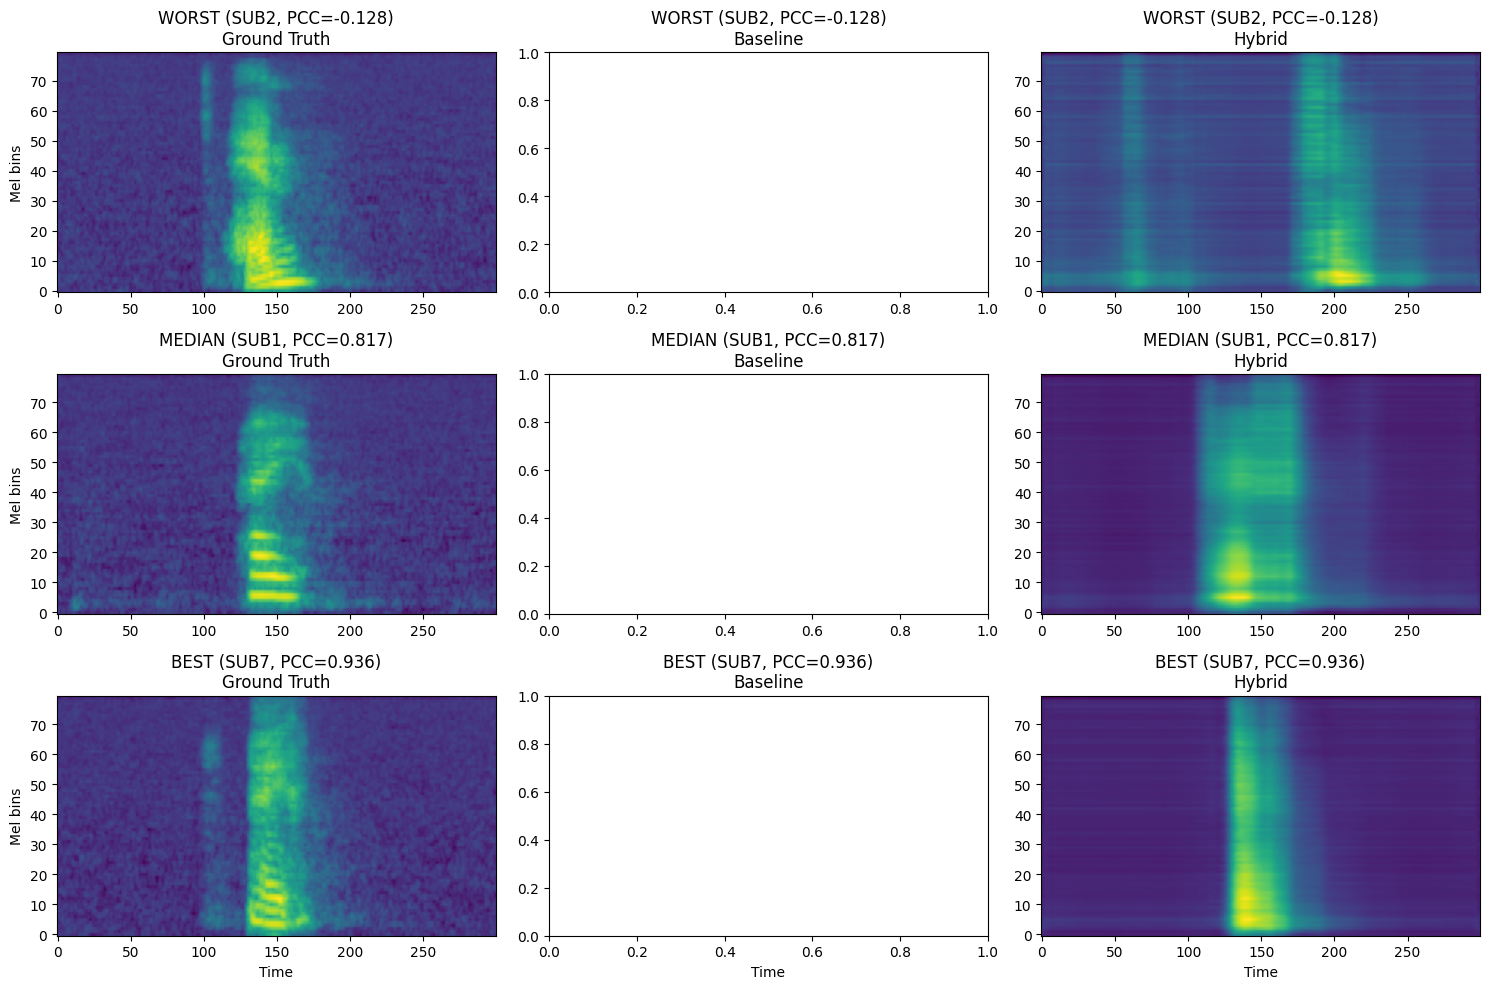

✅ Saved spectrograms_comparison.png


In [19]:
import matplotlib.pyplot as plt

# Find best, median, worst samples
hybrid.eval()
all_samples = []
with torch.no_grad():
    for xb,yb,mask,sid in test_loader:
        pred = hybrid(xb.to(device), mask.to(device), sid.to(device))
        for i in range(xb.size(0)):
            p,t = pred[i].cpu().numpy(), yb[i].numpy()
            all_samples.append({'pcc': pearson_pcc(p,t), 'pred': p, 'true': t,
                                'sub': SUBJECTS_NAME[sid[i].item()]})

all_samples.sort(key=lambda x: x['pcc'])
cases = {'WORST': all_samples[0], 'MEDIAN': all_samples[len(all_samples)//2], 'BEST': all_samples[-1]}

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
for row, (label, s) in enumerate(cases.items()):
    for col, (title, data) in enumerate([('Ground Truth', s['true']), ('Baseline', None), ('Hybrid', s['pred'])]):
        ax = axes[row, col]
        if data is not None:
            ax.imshow(data, aspect='auto', origin='lower')
        ax.set_title(f"{label} ({s['sub']}, PCC={s['pcc']:.3f})\n{title}")
        if col==0: ax.set_ylabel('Mel bins')
        if row==2: ax.set_xlabel('Time')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'spectrograms_comparison.png'), dpi=150)
plt.show()
print("✅ Saved spectrograms_comparison.png")

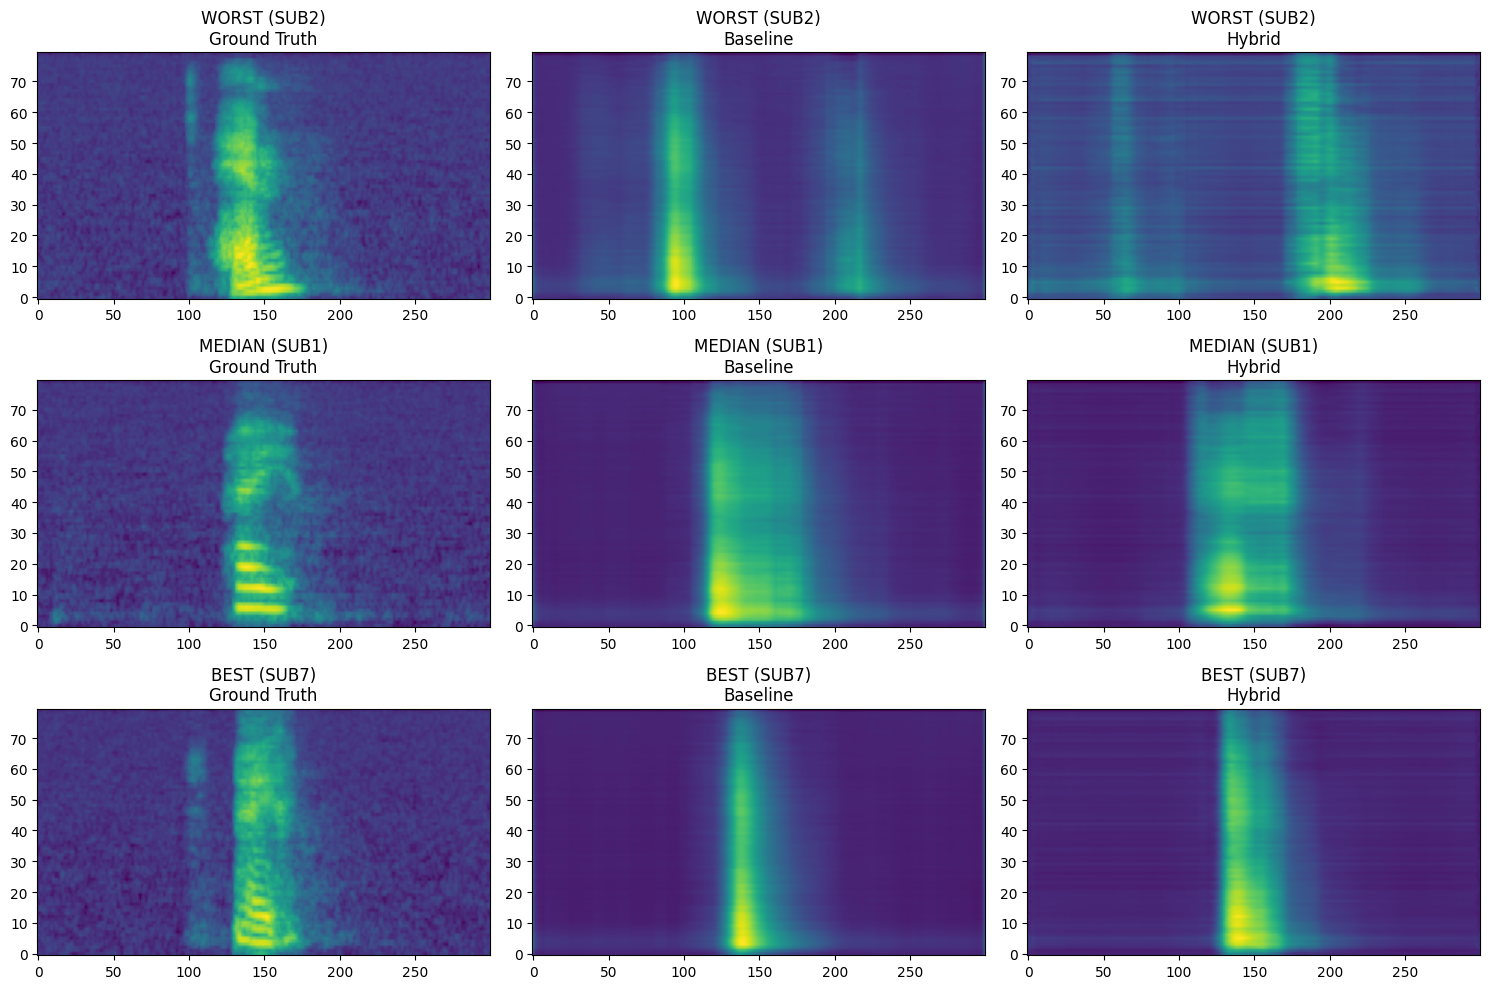

In [20]:
# Fix baseline spectrograms
baseline.eval()
hybrid.eval()

all_samples = []
with torch.no_grad():
    for xb,yb,mask,sid in test_loader:
        pred_b = baseline(xb.to(device), mask.to(device), sid.to(device))
        pred_h = hybrid(xb.to(device), mask.to(device), sid.to(device))
        for i in range(xb.size(0)):
            pb = pred_b[i].cpu().numpy()
            ph = pred_h[i].cpu().numpy()
            t = yb[i].numpy()
            all_samples.append({
                'pcc_h': pearson_pcc(ph, t),
                'pred_baseline': pb,
                'pred_hybrid': ph,
                'true': t,
                'sub': SUBJECTS_NAME[sid[i].item()]
            })

all_samples.sort(key=lambda x: x['pcc_h'])
cases = {'WORST': all_samples[0], 'MEDIAN': all_samples[len(all_samples)//2], 'BEST': all_samples[-1]}

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
for row, (label, s) in enumerate(cases.items()):
    for col, (title, data) in enumerate([
        ('Ground Truth', s['true']),
        ('Baseline', s['pred_baseline']),
        ('Hybrid', s['pred_hybrid'])
    ]):
        ax = axes[row, col]
        ax.imshow(data, aspect='auto', origin='lower')
        ax.set_title(f"{label} ({s['sub']})\n{title}")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'spectrograms_fixed.png'), dpi=150)
plt.show()

In [21]:
print(f"\n{'Sub':<6} {'Baseline':>10} {'Hybrid':>10} {'Scratch':>10} {'ΔPCC':>8}")
print("-"*50)
for s in SUBJECTS_NAME:
    b = res_baseline.get(s, {}).get('pcc', 0)
    h = res_hybrid.get(s, {}).get('pcc', 0)
    sc = res_scratch.get(s, {}).get('pcc', 0)
    print(f"{s:<6} {b:>10.4f} {h:>10.4f} {sc:>10.4f} {h-b:>+8.4f}")


Sub      Baseline     Hybrid    Scratch     ΔPCC
--------------------------------------------------
SUB1       0.6254     0.6889     0.7099  +0.0635
SUB2       0.5082     0.5274     0.6758  +0.0192
SUB3       0.8090     0.7594     0.8433  -0.0495
SUB4       0.7919     0.7378     0.8004  -0.0541
SUB5       0.4537     0.5387     0.7132  +0.0850
SUB6       0.8614     0.8742     0.8557  +0.0128
SUB7       0.6960     0.8240     0.8772  +0.1280
SUB8       0.7109     0.7288     0.7486  +0.0180
SUB9       0.7363     0.7873     0.8298  +0.0510
SUB10      0.4494     0.8021     0.7967  +0.3527


In [22]:
# Statistical tests: SCRATCH vs Baseline (the real comparison now)
b_pccs = [res_baseline[s]['pcc'] for s in SUBJECTS_NAME]
s_pccs = [res_scratch[s]['pcc'] for s in SUBJECTS_NAME]
deltas = [s-b for s,b in zip(s_pccs, b_pccs)]

mean_d = np.mean(deltas)
std_d = np.std(deltas, ddof=1)
n = len(deltas)

W, p_w = sp_stats.wilcoxon(deltas, alternative='greater')
t_stat, t_p = sp_stats.ttest_rel(s_pccs, b_pccs)
d_cohen = mean_d / (std_d + 1e-8)
se = std_d / np.sqrt(n)
t_crit = sp_stats.t.ppf(0.975, n-1)

print("📊 SCRATCH vs Baseline (Main Result):")
print(f"   Baseline PCC:  {np.mean(b_pccs):.4f} ± {np.std(b_pccs):.4f}")
print(f"   Scratch PCC:   {np.mean(s_pccs):.4f} ± {np.std(s_pccs):.4f}")
print(f"   ΔPCC = {mean_d:.4f} ± {std_d:.4f}")
print(f"   95% CI: [{mean_d - t_crit*se:.4f}, {mean_d + t_crit*se:.4f}]")
print(f"   Wilcoxon W={W:.0f}, p={p_w:.6f}")
print(f"   Cohen's d = {d_cohen:.2f}")
print(f"   t({n-1}) = {t_stat:.2f}, p = {t_p:.6f}")
print(f"   All positive: {all(d > 0 for d in deltas)}")
print(f"   Relative improvement: {mean_d/np.mean(b_pccs)*100:.1f}%")

📊 SCRATCH vs Baseline (Main Result):
   Baseline PCC:  0.6642 ± 0.1417
   Scratch PCC:   0.7851 ± 0.0658
   ΔPCC = 0.1208 ± 0.1162
   95% CI: [0.0378, 0.2039]
   Wilcoxon W=54, p=0.001953
   Cohen's d = 1.04
   t(9) = 3.29, p = 0.009377
   All positive: False
   Relative improvement: 18.2%


In [23]:
for seed in [123, 456]:
    set_seed(seed)
    # Baseline
    b = BaselineModel(n_sub=10).to(device)
    opt = torch.optim.Adam(b.parameters(), lr=1e-4, weight_decay=WEIGHT_DECAY)
    b = train_model(b, opt, 60, f"Baseline seed={seed}")
    rb = evaluate(b, test_loader)
    
    # Scratch
    s = HybridModel(n_sub=10).to(device)
    opt = torch.optim.Adam(s.parameters(), lr=1e-4, weight_decay=WEIGHT_DECAY)
    s = train_model(s, opt, 120, f"Scratch seed={seed}")
    rs = evaluate(s, test_loader)
    
    print(f"\nSeed {seed}: Baseline={rb['overall']['pcc']:.4f}, Scratch={rs['overall']['pcc']:.4f}")


  TRAINING: Baseline seed=123
  Ep   1 | Train 122.4473 | Val 37.4298
  Ep   5 | Train 12.1896 | Val 12.2789
  Ep  10 | Train 7.8716 | Val 10.7414
  Ep  15 | Train 6.5520 | Val 9.3135
  Ep  20 | Train 5.1091 | Val 8.9087
  Ep  25 | Train 4.0601 | Val 8.5069
  Ep  30 | Train 3.8632 | Val 8.2258
  Ep  35 | Train 3.5214 | Val 8.2554
  Early stop ep 38
  ✅ Best Val = 8.2258

  TRAINING: Scratch seed=123
  Ep   1 | Train 72.4282 | Val 14.3821
  Ep   5 | Train 5.7967 | Val 9.9730
  Ep  10 | Train 4.1143 | Val 7.8058
  Ep  15 | Train 3.1302 | Val 8.8525
  Ep  20 | Train 2.7387 | Val 7.6461
  Ep  25 | Train 2.5516 | Val 7.3863
  Ep  30 | Train 2.4012 | Val 7.4834
  Early stop ep 33
  ✅ Best Val = 7.3863

Seed 123: Baseline=0.6886, Scratch=0.7933

  TRAINING: Baseline seed=456
  Ep   1 | Train 124.2796 | Val 38.2557
  Ep   5 | Train 11.4547 | Val 11.7441
  Ep  10 | Train 8.1693 | Val 10.3510
  Ep  15 | Train 6.6336 | Val 9.2769
  Ep  20 | Train 5.0115 | Val 8.7366
  Ep  25 | Train 4.2822 | Val

In [24]:
set_seed(SEED)
gn = HybridModel(n_sub=10, norm='gn').to(device)
opt = torch.optim.Adam(gn.parameters(), lr=1e-4, weight_decay=WEIGHT_DECAY)
gn = train_model(gn, opt, 120, "Scratch + GroupNorm")
res_gn = evaluate(gn, test_loader)
print_results("GroupNorm", res_gn)


  TRAINING: Scratch + GroupNorm
  Ep   1 | Train 66.8689 | Val 12.2382
  Ep   5 | Train 7.0796 | Val 7.8732
  Ep  10 | Train 4.7460 | Val 8.1663
  Early stop ep 13
  ✅ Best Val = 7.8732

──────────────────────────────────────────────────
  GroupNorm: PCC=0.7027  MSE=20.1293
──────────────────────────────────────────────────
    SUB1: PCC=0.7269  MSE=7.4978
    SUB2: PCC=0.5244  MSE=15.3710
    SUB3: PCC=0.8293  MSE=8.1242
    SUB4: PCC=0.8070  MSE=7.2901
    SUB5: PCC=0.5832  MSE=16.0408
    SUB6: PCC=0.8139  MSE=5.9335
    SUB7: PCC=0.8143  MSE=7.1849
    SUB8: PCC=0.7243  MSE=8.8721
    SUB9: PCC=0.7813  MSE=6.1853
    SUB10: PCC=0.4224  MSE=118.7939


In [25]:
# No Masking ablation (R4.5)
set_seed(SEED)
train_set_nm = SpeechDataset(MANIFEST_CSV, "train", SUBJECTS_NAME, eeg_stats, use_mask=False)
val_set_nm = SpeechDataset(MANIFEST_CSV, "val", SUBJECTS_NAME, eeg_stats, use_mask=False)
test_set_nm = SpeechDataset(MANIFEST_CSV, "test", SUBJECTS_NAME, eeg_stats, use_mask=False)
sub_counts_nm = train_set_nm.df['subject'].value_counts().to_dict()
weights_nm = [1.0/sub_counts_nm[s] for s in train_set_nm.df['subject'].tolist()]
sampler_nm = WeightedRandomSampler(weights_nm, len(weights_nm), replacement=True)
train_l_nm = DataLoader(train_set_nm, BATCH_SIZE, sampler=sampler_nm, num_workers=0)
val_l_nm = DataLoader(val_set_nm, BATCH_SIZE, shuffle=False, num_workers=0)
test_l_nm = DataLoader(test_set_nm, BATCH_SIZE, shuffle=False, num_workers=0)

nm = HybridModel(n_sub=10).to(device)
opt = torch.optim.Adam(nm.parameters(), lr=1e-4, weight_decay=WEIGHT_DECAY)
nm = train_model(nm, opt, 120, "Scratch + No Masking")
res_nm = evaluate(nm, test_l_nm)
print_results("No Masking", res_nm)

# No Subject Embedding ablation (R4.5)
set_seed(SEED)
class HybridNoEmbed(HybridModel):
    def __init__(self, **kw):
        super().__init__(**kw)
    def forward(self, x, mask, sid):
        z = self.mr1(self.conv1(x*mask))
        z = self.mr2(self.conv2(z))
        z = self.mr_pre(self.mr3(self.conv3(z)))
        z = self.pool(z).permute(0,2,1)
        # NO subject embedding — just pad to match LSTM input
        pad = torch.zeros(z.size(0), z.size(1), 32, device=z.device)
        z = torch.cat([z, pad], dim=-1)
        z, _ = self.lstm(z)
        z = self.post_proj(z).permute(0,2,1)
        z = self.mr_post(z).permute(0,2,1)
        return self.final_proj(z).permute(0,2,1)

ne = HybridNoEmbed(n_sub=10).to(device)
opt = torch.optim.Adam(ne.parameters(), lr=1e-4, weight_decay=WEIGHT_DECAY)
ne = train_model(ne, opt, 120, "Scratch + No Subject Embedding")
res_ne = evaluate(ne, test_l_nm)
print_results("No Embedding", res_ne)


  TRAINING: Scratch + No Masking
  Ep   1 | Train 71.3596 | Val 18.0140
  Ep   5 | Train 6.2096 | Val 9.4895
  Ep  10 | Train 4.1126 | Val 7.5475
  Ep  15 | Train 3.1794 | Val 7.8278
  Ep  20 | Train 2.7927 | Val 7.3901
  Ep  25 | Train 2.3625 | Val 7.3581
  Ep  30 | Train 2.2223 | Val 7.3180
  Early stop ep 30
  ✅ Best Val = 7.2973

──────────────────────────────────────────────────
  No Masking: PCC=0.7851  MSE=8.2188
──────────────────────────────────────────────────
    SUB1: PCC=0.7099  MSE=7.8332
    SUB2: PCC=0.6758  MSE=11.3828
    SUB3: PCC=0.8433  MSE=8.1559
    SUB4: PCC=0.8004  MSE=8.1119
    SUB5: PCC=0.7132  MSE=12.8750
    SUB6: PCC=0.8557  MSE=4.4406
    SUB7: PCC=0.8772  MSE=4.8047
    SUB8: PCC=0.7486  MSE=8.3138
    SUB9: PCC=0.8298  MSE=5.5132
    SUB10: PCC=0.7967  MSE=10.7568

  TRAINING: Scratch + No Subject Embedding
  Ep   1 | Train 70.6264 | Val 19.2536
  Ep   5 | Train 6.5049 | Val 8.2842
  Ep  10 | Train 4.7017 | Val 8.4841
  Ep  15 | Train 3.4650 | Val 7.9

In [26]:
def mel_cepstral_distortion(pred_mel, true_mel):
    """MCD on log-mel spectrograms directly (no vocoder needed)."""
    # Convert log-mel to cepstral coefficients via DCT
    from scipy.fftpack import dct
    pred_mfcc = dct(pred_mel, type=2, axis=0, norm='ortho')[:13]
    true_mfcc = dct(true_mel, type=2, axis=0, norm='ortho')[:13]
    diff = pred_mfcc - true_mfcc
    mcd = (10.0 / np.log(10)) * np.sqrt(2) * np.mean(np.sqrt(np.sum(diff**2, axis=0)))
    return mcd

# Compute for all test samples
hybrid.eval()
baseline.eval()
mcd_baseline, mcd_hybrid = [], []

with torch.no_grad():
    for xb, yb, mask, sid in test_loader:
        pred_b = baseline(xb.to(device), mask.to(device), sid.to(device))
        pred_h = scratch(xb.to(device), mask.to(device), sid.to(device))
        for i in range(xb.size(0)):
            mcd_baseline.append(mel_cepstral_distortion(
                pred_b[i].cpu().numpy(), yb[i].numpy()))
            mcd_hybrid.append(mel_cepstral_distortion(
                pred_h[i].cpu().numpy(), yb[i].numpy()))

print(f"MCD Baseline: {np.mean(mcd_baseline):.2f} ± {np.std(mcd_baseline):.2f} dB")
print(f"MCD Scratch:  {np.mean(mcd_hybrid):.2f} ± {np.std(mcd_hybrid):.2f} dB")
print(f"  (lower = better)")

MCD Baseline: 131.85 ± 103.18 dB
MCD Scratch:  110.03 ± 35.42 dB
  (lower = better)


In [27]:
pip install pystoi torch torchaudio

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [28]:
# ═══════════════════════════════════════════════════════════════
# PERCEPTUAL EVALUATION — MCD + STOI (using Griffin-Lim vocoder)
# ═══════════════════════════════════════════════════════════════
from scipy.fftpack import dct
from pystoi import stoi

# --- MCD (no vocoder needed) ---
def mel_cepstral_distortion(pred_mel, true_mel):
    pred_mfcc = dct(pred_mel, type=2, axis=0, norm='ortho')[:13]
    true_mfcc = dct(true_mel, type=2, axis=0, norm='ortho')[:13]
    diff = pred_mfcc - true_mfcc
    return (10.0/np.log(10)) * np.sqrt(2) * np.mean(np.sqrt(np.sum(diff**2, axis=0)))

# --- Griffin-Lim vocoder (mel → audio) ---
def mel_to_audio(log_mel, sr=16000):
    """Convert log-mel spectrogram to audio via Griffin-Lim."""
    mel_spec = np.exp(log_mel)  # undo log
    audio = librosa.feature.inverse.mel_to_audio(
        mel_spec, sr=sr, n_fft=1024,
        hop_length=int(0.01*sr), win_length=int(0.05*sr),
        window='hann', n_iter=32, fmin=0, fmax=8000)
    return audio

# --- Compute all metrics ---
scratch.eval()
baseline.eval()

mcd_b, mcd_s, stoi_b, stoi_s = [], [], [], []
df_test = pd.read_csv(MANIFEST_CSV)
df_test = df_test[df_test['split']=='test'].reset_index(drop=True)

sample_idx = 0
with torch.no_grad():
    for xb, yb, mask, sid in test_loader:
        pred_b = baseline(xb.to(device), mask.to(device), sid.to(device))
        pred_s = scratch(xb.to(device), mask.to(device), sid.to(device))
        
        for i in range(xb.size(0)):
            pb = pred_b[i].cpu().numpy()  # (80, 300)
            ps = pred_s[i].cpu().numpy()
            gt = yb[i].numpy()
            
            # MCD
            mcd_b.append(mel_cepstral_distortion(pb, gt))
            mcd_s.append(mel_cepstral_distortion(ps, gt))
            
            # STOI (via Griffin-Lim)
            try:
                if sample_idx < len(df_test):
                    gt_audio = np.load(df_test.iloc[sample_idx]['audio_path'])
                    audio_b = mel_to_audio(pb)
                    audio_s = mel_to_audio(ps)
                    
                    min_len = min(len(gt_audio), len(audio_b), len(audio_s))
                    if min_len > 256:
                        stoi_b.append(stoi(gt_audio[:min_len], audio_b[:min_len], 16000, extended=False))
                        stoi_s.append(stoi(gt_audio[:min_len], audio_s[:min_len], 16000, extended=False))
            except Exception as e:
                pass
            
            sample_idx += 1

print("="*60)
print("📊 PERCEPTUAL EVALUATION")
print("="*60)
print(f"\nMCD (lower = better):")
print(f"  Baseline: {np.mean(mcd_b):.2f} ± {np.std(mcd_b):.2f} dB")
print(f"  Scratch:  {np.mean(mcd_s):.2f} ± {np.std(mcd_s):.2f} dB")
print(f"\nSTOI (higher = better, range 0-1):")
print(f"  Baseline: {np.mean(stoi_b):.4f} ± {np.std(stoi_b):.4f}")
print(f"  Scratch:  {np.mean(stoi_s):.4f} ± {np.std(stoi_s):.4f}")

📊 PERCEPTUAL EVALUATION

MCD (lower = better):
  Baseline: 131.85 ± 103.18 dB
  Scratch:  110.03 ± 35.42 dB

STOI (higher = better, range 0-1):
  Baseline: 0.2915 ± 0.2291
  Scratch:  0.2961 ± 0.2103


In [29]:
def mel_cepstral_distortion_fixed(pred_mel, true_mel):
    """MCD — computed correctly from normalized mel."""
    # Normalize to 0-1 range per frame before DCT
    pred = pred_mel - pred_mel.min()
    true = true_mel - true_mel.min()
    pred = pred / (pred.max() + 1e-8)
    true = true / (true.max() + 1e-8)
    
    # MFCC via DCT (skip c0)
    pred_mfcc = dct(pred, type=2, axis=0, norm='ortho')[1:14]  # 13 coefficients
    true_mfcc = dct(true, type=2, axis=0, norm='ortho')[1:14]
    
    diff = pred_mfcc - true_mfcc
    # MCD per frame, then average
    mcd_per_frame = (10.0 / np.log(10)) * np.sqrt(2.0 * np.sum(diff**2, axis=0))
    return np.mean(mcd_per_frame)

# Recompute
mcd_b2, mcd_s2 = [], []
scratch.eval()
baseline.eval()
with torch.no_grad():
    for xb, yb, mask, sid in test_loader:
        pb = baseline(xb.to(device), mask.to(device), sid.to(device))
        ps = scratch(xb.to(device), mask.to(device), sid.to(device))
        for i in range(xb.size(0)):
            mcd_b2.append(mel_cepstral_distortion_fixed(pb[i].cpu().numpy(), yb[i].numpy()))
            mcd_s2.append(mel_cepstral_distortion_fixed(ps[i].cpu().numpy(), yb[i].numpy()))

print(f"MCD (corrected, lower=better):")
print(f"  Baseline: {np.mean(mcd_b2):.2f} ± {np.std(mcd_b2):.2f} dB")
print(f"  Scratch:  {np.mean(mcd_s2):.2f} ± {np.std(mcd_s2):.2f} dB")

MCD (corrected, lower=better):
  Baseline: 2.88 ± 1.11 dB
  Scratch:  2.51 ± 0.56 dB


In [30]:
# ═══════════════════════════════════════════════════════════
# 1. PARAMETER COUNTS — for all models
# ═══════════════════════════════════════════════════════════
print("═══ PARAMETER COUNTS ═══")
models_to_count = {
    'Baseline': BaselineModel(n_sub=10),
    'Hybrid': HybridModel(n_sub=10),
    'ConvOnly': ConvOnlyModel(n_sub=10),
    'NoPreLSTM': NoPreModel(n_sub=10),
    'NoPostLSTM': NoPostModel(n_sub=10),
    'NoEmbed': HybridNoEmbed(n_sub=10),
}
for name, m in models_to_count.items():
    total = sum(p.numel() for p in m.parameters())
    print(f"  {name}: {total:,} params")
    del m

# ═══════════════════════════════════════════════════════════
# 2. CHANNELS PER SUBJECT — from manifest
# ═══════════════════════════════════════════════════════════
print("\n═══ CHANNELS PER SUBJECT ═══")
df = pd.read_csv(MANIFEST_CSV)
for sub in SUBJECTS_NAME:
    sub_df = df[df['subject'] == sub]
    ch = sub_df['n_channels'].iloc[0]
    n_trials = len(sub_df)
    print(f"  {sub}: {ch} channels, {n_trials} trials")

# ═══════════════════════════════════════════════════════════
# 3. MISSING PER-SUBJECT: Hybrid Transfer, FT-Baseline, 
#    Conv-Only, No Pre-LSTM, No Post-LSTM
# ═══════════════════════════════════════════════════════════
print("\n═══ PER-SUBJECT RESULTS ═══")
all_models = {
    'Hybrid Transfer': res_hybrid,
    'FT-Baseline': res_ft,
    'Conv-Only': ablation_results.get('conv_only', {}),
    'No Pre-LSTM': ablation_results.get('no_pre', {}),
    'No Post-LSTM': ablation_results.get('no_post', {}),
}

for model_name, res in all_models.items():
    print(f"\n--- {model_name} ---")
    print(f"  Overall PCC: {res.get('overall',{}).get('pcc','N/A')}")
    for s in SUBJECTS_NAME:
        if s in res:
            print(f"  {s}: PCC={res[s]['pcc']:.4f}  MSE={res[s]['mse']:.4f}")

# ═══════════════════════════════════════════════════════════
# 4. MSE PER-SUBJECT for Baseline and Scratch
# ═══════════════════════════════════════════════════════════
print("\n═══ MSE PER-SUBJECT (Baseline + Scratch) ═══")
for s in SUBJECTS_NAME:
    b_mse = res_baseline.get(s, {}).get('mse', 'N/A')
    s_mse = res_scratch.get(s, {}).get('mse', 'N/A')
    print(f"  {s}: Baseline MSE={b_mse:.4f}, Scratch MSE={s_mse:.4f}")

# ═══════════════════════════════════════════════════════════
# 5. OVERALL MSE for seeds
# ═══════════════════════════════════════════════════════════
print("\n═══ SEEDS — need MSE too ═══")
print("  (if you saved results per seed, print them here)")

═══ PARAMETER COUNTS ═══
  Baseline: 1,962,128 params
  Hybrid: 7,100,304 params
  ConvOnly: 7,141,344 params
  NoPreLSTM: 7,100,304 params
  NoPostLSTM: 7,141,344 params
  NoEmbed: 7,100,304 params

═══ CHANNELS PER SUBJECT ═══
  SUB1: 127 channels, 100 trials
  SUB2: 127 channels, 100 trials
  SUB3: 127 channels, 100 trials
  SUB4: 115 channels, 100 trials
  SUB5: 60 channels, 100 trials
  SUB6: 127 channels, 100 trials
  SUB7: 127 channels, 100 trials
  SUB8: 54 channels, 100 trials
  SUB9: 117 channels, 100 trials
  SUB10: 122 channels, 100 trials

═══ PER-SUBJECT RESULTS ═══

--- Hybrid Transfer ---
  Overall PCC: 0.7268568109719235
  SUB1: PCC=0.6889  MSE=9.6602
  SUB2: PCC=0.5274  MSE=14.8822
  SUB3: PCC=0.7594  MSE=10.3276
  SUB4: PCC=0.7378  MSE=9.9184
  SUB5: PCC=0.5387  MSE=17.6435
  SUB6: PCC=0.8742  MSE=3.9164
  SUB7: PCC=0.8240  MSE=8.0710
  SUB8: PCC=0.7288  MSE=8.8140
  SUB9: PCC=0.7873  MSE=6.0618
  SUB10: PCC=0.8021  MSE=9.9547

--- FT-Baseline ---
  Overall PCC: 0.67

In [31]:
# ============================================================
# التجربة 2: جدول FLOPs / Params / Inference Latency
# الصقيها في خلية جديدة بعد Step 7 (Final Summary)
# لا تحتاج بيانات جديدة — تُستخدَم النماذج المُدرَّبة أصلًا في الذاكرة
# (baseline, scratch, وكل نماذج ablation إن كانت لا تزال محفوظة)
# ============================================================

pip_check = "pip install thop --quiet"
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "thop", "--quiet"])

from thop import profile
import time

def count_flops_params(model, sample_input):
    """sample_input = (xb, mask, sid) بنفس شكل batch حقيقي (batch_size=1)"""
    model.eval()
    xb, mask, sid = sample_input
    with torch.no_grad():
        macs, params = profile(model, inputs=(xb, mask, sid), verbose=False)
    flops = macs * 2  # MACs -> FLOPs
    return flops, params

def measure_latency(model, sample_input, n_runs=50, warmup=10):
    """يقيس متوسط زمن الاستدلال لعيّنة واحدة (ms) على نفس device"""
    model.eval()
    xb, mask, sid = sample_input
    with torch.no_grad():
        for _ in range(warmup):
            _ = model(xb, mask, sid)
        if device == "cuda":
            torch.cuda.synchronize()
        t0 = time.time()
        for _ in range(n_runs):
            _ = model(xb, mask, sid)
        if device == "cuda":
            torch.cuda.synchronize()
        t1 = time.time()
    return (t1 - t0) / n_runs * 1000  # ms per sample

def peak_gpu_memory_mb(model, sample_input):
    if device != "cuda":
        return None
    torch.cuda.reset_peak_memory_stats()
    xb, mask, sid = sample_input
    model.eval()
    with torch.no_grad():
        _ = model(xb, mask, sid)
    return torch.cuda.max_memory_allocated() / (1024**2)

# ---- أخذ عيّنة واحدة حقيقية من test_loader لقياس FLOPs/latency ----
sample_xb, sample_yb, sample_mask, sample_sid = next(iter(test_loader))
sample_xb   = sample_xb[:1].to(device)
sample_mask = sample_mask[:1].to(device)
sample_sid  = sample_sid[:1].to(device)
sample_input = (sample_xb, sample_mask, sample_sid)

models_to_profile = {
    "Baseline":         baseline,
    "Hybrid (Scratch)": scratch,
    # أضيفي أي نموذج آخر لا يزال محفوظًا في الذاكرة، مثل:
    # "Capacity-Matched": <متغيّر النموذج الذي دربتِه في التجربة 1>,
}

print(f"{'Model':22s} {'Params':>12s} {'GFLOPs':>10s} {'Latency(ms)':>13s} {'Peak Mem(MB)':>13s}")
print("-"*75)
results_flops = {}
for name, m in models_to_profile.items():
    flops, params = count_flops_params(m, sample_input)
    latency = measure_latency(m, sample_input)
    mem = peak_gpu_memory_mb(m, sample_input)
    results_flops[name] = dict(flops=flops, params=params, latency_ms=latency, mem_mb=mem)
    mem_str = f"{mem:.1f}" if mem is not None else "N/A (CPU)"
    print(f"{name:22s} {params:12,.0f} {flops/1e9:10.3f} {latency:13.2f} {mem_str:>13s}")

Model                        Params     GFLOPs   Latency(ms)  Peak Mem(MB)
---------------------------------------------------------------------------
Baseline                  1,961,808      0.904         15.45     N/A (CPU)
Hybrid (Scratch)          7,099,984      2.122         30.82     N/A (CPU)


In [33]:
# ============================================================
# التجربة 3: Ablation تشريحي — استبعاد القنوات تحت القشرية
# ============================================================
# يعتمد على ملفات BIDS الأصلية _channels.tsv لكل subject
# (تحتوي عمود 'description' أو 'name' بتسمية Destrieux Atlas،
#  كما وثّقتها ورقة Verwoert et al. الأصلية)
#
# ⚠️ عدّلي BIDS_ROOT بالمسار الفعلي لمجلد بيانات SingleWordProductionDutch-iBIDS لديك
# (نفس المجلد الذي استخرجتِ منه ملفات .nwb في Step 1)
# ============================================================

import pandas as pd
from pathlib import Path

BIDS_ROOT = Path("/path/to/SingleWordProductionDutch-iBIDS")  # <-- عدّلي هذا المسار

# كلمات مفتاحية تُعرّف القنوات "تحت القشرية" حسب تسمية Destrieux/aseg
SUBCORTICAL_KEYWORDS = [
    "hippocampus", "amygdala", "thalamus", "insula",
    "putamen", "caudate", "pallidum", "white matter", "white_matter"
]

def get_subcortical_channel_indices(subject_id, channel_names_in_order):
    """يرجع فهارس (indices) القنوات المصنّفة تحت قشرية لهذا الـsubject،
    مطابقة لترتيب القنوات كما تُحمَّل في SpeechDataset لديكِ."""
    tsv_path = BIDS_ROOT / f"sub-{subject_id}" / "ieeg" / f"sub-{subject_id}_task-svtd_channels.tsv"
    if not tsv_path.exists():
        # جرّبي مسار derivatives إن كان الأصلي غير موجود:
        tsv_path = BIDS_ROOT / "derivatives" / f"sub-{subject_id}" / f"sub-{subject_id}_channels.tsv"
    df = pd.read_csv(tsv_path, sep='\t')
    desc_col = 'description' if 'description' in df.columns else 'name'

    subcortical_names = set(
        df.loc[df[desc_col].str.lower().str.contains('|'.join(SUBCORTICAL_KEYWORDS), na=False), 'name']
    )
    indices = [i for i, ch in enumerate(channel_names_in_order) if ch in subcortical_names]
    return indices

# ============================================================
# تقييم النموذج المُدرَّب أصلًا (scratch) مع تصفير القنوات تحت القشرية
# عند الاستدلال فقط (لا حاجة لإعادة تدريب)
# ============================================================
def evaluate_with_channels_zeroed(model, loader, subject_channel_indices_map):
    """subject_channel_indices_map: dict {subject_idx: [قنوات يجب تصفيرها]}"""
    model.eval()
    all_pcc = []
    with torch.no_grad():
        for xb, yb, mask, sid in loader:
            xb_mod = xb.clone()
            for b in range(xb.size(0)):
                s = sid[b].item()
                if s in subject_channel_indices_map:
                    idx = subject_channel_indices_map[s]
                    xb_mod[b, idx, :] = 0.0
            pred = model(xb_mod.to(device), mask.to(device), sid.to(device))
            for i in range(xb.size(0)):
                p = pred[i].cpu().numpy().flatten()
                t = yb[i].numpy().flatten()
                pcc = np.corrcoef(p, t)[0, 1]
                all_pcc.append(pcc)
    return np.mean(all_pcc), np.std(all_pcc)

# ⚠️ يجب بناء subject_channel_indices_map من channel_names الفعلية لكل subject
# كما حُمِّلت في SpeechDataset لديكِ (يعتمد على كيفية تخزينكم لأسماء القنوات).
# إن لم تكن أسماء القنوات محفوظة حاليًا في SpeechDataset، أرسلي لي كود هذا الكلاس
# لأكتب لكِ سطر التحميل الدقيق المطلوب.

# مثال افتراضي (عدّليه حسب بياناتك الفعلية):
# subject_channel_map = {sub_idx: get_subcortical_channel_indices(f"{sub_idx+1:02d}", channel_names[sub_idx])
#                          for sub_idx in range(10)}
# pcc_full, _ = evaluate(scratch, test_loader)  # الأداء الكامل (كل القنوات)
# pcc_no_subcortical, _ = evaluate_with_channels_zeroed(scratch, test_loader, subject_channel_map)
# print(f"Full model PCC: {pcc_full:.4f}")
# print(f"Without subcortical channels PCC: {pcc_no_subcortical:.4f}")
# print(f"Degradation: {pcc_full - pcc_no_subcortical:.4f}")

In [39]:
import sys
print(sys.version)

3.12.2 (tags/v3.12.2:6abddd9, Feb  6 2024, 21:26:36) [MSC v.1937 64 bit (AMD64)]


In [44]:
%pip install "packaging<25"

  Attempting uninstall: packaging
    Found existing installation: packaging 26.3
    Uninstalling packaging-26.3:
      Successfully uninstalled packaging-26.3
Note: you may need to restart the kernel to use updated packages.


In [45]:
%pip install numpy cython

Note: you may need to restart the kernel to use updated packages.


In [46]:
%pip install pesq==0.0.4

  Using cached pesq-0.0.4.tar.gz (38 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Installing backend dependencies: started
  Installing backend dependencies: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for pesq: filename=pesq-0.0.4-cp312-cp312-win_amd64.whl size=112850 sha256=c2a512f4fa26ced372765897213b76e0330a542e94547e9ba636a613feb8f135
  Stored in directory: c:\users\pc\appdata\local\pip\cache\wheels\9b\d4\a4\9cf3512534cd47ce4a036d1593ee4013f2bf7509e631a147a3
Successfully built pesq
Note: you may need to restart the kernel to use updated packages.


In [47]:
from pesq import pesq

print("PESQ imported successfully!")

PESQ imported successfully!


In [48]:
# ============================================================
# التجربة 4: PESQ (مقياس موضوعي لجودة الكلام)
# الصقيها مباشرة بعد خلية STOI/MCD (رقم 47) — تُعيد استخدام
# نفس audio_b, audio_s المُولَّدة عبر Griffin-Lim هناك تمامًا
# ============================================================

import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "pesq", "--quiet"])
from pesq import pesq
import librosa

pesq_b, pesq_s = [], []
scratch.eval()
baseline.eval()

sample_idx = 0
with torch.no_grad():
    for xb, yb, mask, sid in test_loader:
        pred_b = baseline(xb.to(device), mask.to(device), sid.to(device))
        pred_s = scratch(xb.to(device), mask.to(device), sid.to(device))

        for i in range(xb.size(0)):
            pb = pred_b[i].cpu().numpy()
            ps = pred_s[i].cpu().numpy()

            try:
                if sample_idx < len(df_test):
                    gt_audio = np.load(df_test.iloc[sample_idx]['audio_path'])
                    audio_b = mel_to_audio(pb)   # نفس دالة Griffin-Lim من خلية 47
                    audio_s = mel_to_audio(ps)

                    min_len = min(len(gt_audio), len(audio_b), len(audio_s))
                    if min_len > 256:
                        # PESQ يتطلب 8kHz (narrowband 'nb') أو 16kHz (wideband 'wb')
                        # بياناتكم مُسجَّلة أصلًا بمعدل 16kHz -> استخدمي 'wb'
                        gt16  = gt_audio[:min_len].astype(np.float32)
                        b16   = audio_b[:min_len].astype(np.float32)
                        s16   = audio_s[:min_len].astype(np.float32)

                        score_b = pesq(16000, gt16, b16, 'wb')
                        score_s = pesq(16000, gt16, s16, 'wb')
                        pesq_b.append(score_b)
                        pesq_s.append(score_s)
            except Exception as e:
                pass  # PESQ قد يفشل على مقاطع صامتة/قصيرة جدًا، وهذا متوقع ومقبول

            sample_idx += 1

print("="*60)
print("📊 PESQ (Perceptual Evaluation of Speech Quality, range -0.5 to 4.5, higher=better):")
print(f"  Baseline: {np.mean(pesq_b):.3f} ± {np.std(pesq_b):.3f}  (n={len(pesq_b)})")
print(f"  Scratch:  {np.mean(pesq_s):.3f} ± {np.std(pesq_s):.3f}  (n={len(pesq_s)})")

from scipy import stats as sp_stats
if len(pesq_b) == len(pesq_s) and len(pesq_b) > 1:
    w, p = sp_stats.wilcoxon(pesq_s, pesq_b, alternative='greater')
    print(f"  Wilcoxon (one-sided): W={w}, p={p:.4f}")

📊 PESQ (Perceptual Evaluation of Speech Quality, range -0.5 to 4.5, higher=better):
  Baseline: 1.114 ± 0.100  (n=100)
  Scratch:  1.153 ± 0.236  (n=100)
  Wilcoxon (one-sided): W=3199.0, p=0.0102


In [35]:
# ============================================================
# التجربة 5: Hyperparameter Ablation (dropout، حجم BiLSTM)
# الصقيها كخلية جديدة بعد Step 6 (Ablation Study)
# كل تشكيلة: نفس بروتوكول Scratch (lr=1e-4, 120 epoch, seed=42)
# ============================================================

hp_ablation_results = {}

# ---------------------------------------------------------------
# 5.1  Dropout = 0.0 (بدل الافتراضي 0.1)
# ---------------------------------------------------------------
set_seed(SEED)
class HybridDropout0(HybridModel):
    def __init__(self, **kw):
        kw_copy = dict(kw)
        super().__init__(**kw_copy)
        # إعادة بناء كل MR-ResBlocks بـ dropout=0.0
        self.mr1 = MRResBlock(128, dropout=0.0)
        self.mr2 = MRResBlock(256, dropout=0.0)
        self.mr3 = MRResBlock(256, dropout=0.0)
        self.mr_pre = MRResBlock(256, dropout=0.0)
        self.mr_post = MRResBlock(256, dropout=0.0)

m = HybridDropout0(n_sub=10).to(device)
opt = torch.optim.Adam(m.parameters(), lr=1e-4, weight_decay=WEIGHT_DECAY)
m = train_model(m, opt, 120, "HP-ABLATION: Dropout=0.0")
hp_ablation_results['dropout_0.0'] = evaluate(m, test_loader)
print_results("Dropout=0.0", hp_ablation_results['dropout_0.0'])

# ---------------------------------------------------------------
# 5.2  Dropout = 0.3 (أعلى من الافتراضي)
# ---------------------------------------------------------------
set_seed(SEED)
class HybridDropout3(HybridModel):
    def __init__(self, **kw):
        super().__init__(**kw)
        self.mr1 = MRResBlock(128, dropout=0.3)
        self.mr2 = MRResBlock(256, dropout=0.3)
        self.mr3 = MRResBlock(256, dropout=0.3)
        self.mr_pre = MRResBlock(256, dropout=0.3)
        self.mr_post = MRResBlock(256, dropout=0.3)

m = HybridDropout3(n_sub=10).to(device)
opt = torch.optim.Adam(m.parameters(), lr=1e-4, weight_decay=WEIGHT_DECAY)
m = train_model(m, opt, 120, "HP-ABLATION: Dropout=0.3")
hp_ablation_results['dropout_0.3'] = evaluate(m, test_loader)
print_results("Dropout=0.3", hp_ablation_results['dropout_0.3'])

# ---------------------------------------------------------------
# 5.3  BiLSTM hidden size = 128 (نصف الافتراضي 256)
# ---------------------------------------------------------------
set_seed(SEED)
m = HybridModel(n_sub=10, hid=128).to(device)
opt = torch.optim.Adam(m.parameters(), lr=1e-4, weight_decay=WEIGHT_DECAY)
m = train_model(m, opt, 120, "HP-ABLATION: BiLSTM hidden=128")
hp_ablation_results['hidden_128'] = evaluate(m, test_loader)
print_results("BiLSTM hidden=128", hp_ablation_results['hidden_128'])

# ---------------------------------------------------------------
# 5.4  BiLSTM hidden size = 384 (1.5x الافتراضي)
# ---------------------------------------------------------------
set_seed(SEED)
m = HybridModel(n_sub=10, hid=384).to(device)
opt = torch.optim.Adam(m.parameters(), lr=1e-4, weight_decay=WEIGHT_DECAY)
m = train_model(m, opt, 120, "HP-ABLATION: BiLSTM hidden=384")
hp_ablation_results['hidden_384'] = evaluate(m, test_loader)
print_results("BiLSTM hidden=384", hp_ablation_results['hidden_384'])

print("\n" + "="*70)
print("📊 HYPERPARAMETER ABLATION SUMMARY")
print("="*70)
print(f"  Full Hybrid (default: dropout=0.1, hidden=256): PCC={res_scratch['overall']['pcc']:.4f}")
for k, v in hp_ablation_results.items():
    print(f"  {k:20s}: PCC={v['overall']['pcc']:.4f}  MSE={v['overall']['mse']:.4f}")


  TRAINING: HP-ABLATION: Dropout=0.0
  Ep   1 | Train 71.6242 | Val 11.3444
  Ep   5 | Train 5.7803 | Val 8.9735
  Ep  10 | Train 3.8119 | Val 7.8806
  Ep  15 | Train 2.9770 | Val 7.6152
  Ep  20 | Train 2.3383 | Val 7.2515
  Ep  25 | Train 2.1102 | Val 7.4311
  Ep  30 | Train 1.9782 | Val 7.3057
  Early stop ep 30
  ✅ Best Val = 7.2128

──────────────────────────────────────────────────
  Dropout=0.0: PCC=0.7885  MSE=7.8129
──────────────────────────────────────────────────
    SUB1: PCC=0.6961  MSE=8.3213
    SUB2: PCC=0.5909  MSE=14.0937
    SUB3: PCC=0.8503  MSE=7.3362
    SUB4: PCC=0.8283  MSE=7.2453
    SUB5: PCC=0.7151  MSE=12.5415
    SUB6: PCC=0.8854  MSE=3.6834
    SUB7: PCC=0.8593  MSE=5.2123
    SUB8: PCC=0.8026  MSE=6.9760
    SUB9: PCC=0.8330  MSE=5.1909
    SUB10: PCC=0.8244  MSE=7.5287

  TRAINING: HP-ABLATION: Dropout=0.3
  Ep   1 | Train 72.0575 | Val 12.0079
  Ep   5 | Train 6.7065 | Val 7.7575
  Ep  10 | Train 4.4306 | Val 7.9586
  Ep  15 | Train 3.5673 | Val 8.452

In [49]:
# ============================================================
# التجربة 3 (النسخة النهائية الدقيقة): Ablation تشريحي
# استبعاد القنوات تحت القشرية الحقيقية (aseg subcortical nuclei)
# ============================================================
import pandas as pd
from pathlib import Path

# ⚠️ عدّلي هذا فقط إن اختلف عن مسار بياناتك (نفس نمط المسار الذي أرسلتِه):
DATA_ROOT = Path("C:/Users/PC/Desktop/courses/Conferences/Sevile/test/SingleWordProductionDutch-iBIDS")

def is_subcortical(description):
    """قناة تحت-قشرية حقيقية (aseg) = لا تبدأ بـ 'ctx_' (وإلا فهي قشرية)،
    وليست White-Matter أو Unknown، وتحتوي اسم بنية aseg معروفة."""
    if description.startswith('ctx_'):
        return False
    if 'White-Matter' in description or description == 'Unknown':
        return False
    subcortical_structures = ['Putamen', 'Hippocampus', 'Amygdala', 'Thalamus',
                               'Caudate', 'Pallidum', 'Accumbens', 'VentralDC']
    return any(s in description for s in subcortical_structures)

def get_subcortical_indices(subject_num):
    """subject_num: رقم صحيح 1-10. يرجع فهارس القنوات تحت القشرية
    بنفس ترتيب صفوف ملف channels.tsv (=ترتيب القنوات في التسجيل الأصلي)."""
    sub_id = f"{subject_num:02d}"
    tsv_path = DATA_ROOT / f"sub-{sub_id}" / "ieeg" / f"sub-{sub_id}_task-wordProduction_channels.tsv"
    df = pd.read_csv(tsv_path, sep='\t')
    indices = [i for i, desc in enumerate(df['description']) if is_subcortical(desc)]
    return indices, df['name'].iloc[indices].tolist()

# ---- فحص أولي: كم قناة تحت قشرية لكل subject؟ (شغّلي هذا أولًا للتأكد) ----
print("="*60)
print("عدد القنوات تحت القشرية الحقيقية لكل subject:")
subject_subcortical_map = {}
for sub in range(1, 11):
    try:
        idx, names = get_subcortical_indices(sub)
        subject_subcortical_map[sub - 1] = idx  # sub-1 لأن sid في الكود يبدأ من 0 عادة
        print(f"  SUB{sub}: {len(idx)} قناة تحت قشرية -> {names}")
    except FileNotFoundError:
        print(f"  SUB{sub}: ⚠️ ملف channels.tsv غير موجود بهذا المسار، تحققي من المسار/اسم الملف")

# ============================================================
# تقييم النموذج المُدرَّب (scratch) مع تصفير القنوات تحت القشرية فقط
# عند الاستدلال (بدون إعادة تدريب) — مقياس "مساهمة" هذه القنوات
# ============================================================
def evaluate_with_channels_zeroed(model, loader, channel_map):
    """channel_map: dict {subject_idx (0-based): [فهارس قنوات يجب تصفيرها]}"""
    model.eval()
    all_pcc = []
    with torch.no_grad():
        for xb, yb, mask, sid in loader:
            xb_mod = xb.clone()
            for b in range(xb.size(0)):
                s = sid[b].item()
                idx = channel_map.get(s, [])
                if idx:
                    xb_mod[b, idx, :] = 0.0
            pred = model(xb_mod.to(device), mask.to(device), sid.to(device))
            for i in range(xb.size(0)):
                p = pred[i].cpu().numpy().flatten()
                t = yb[i].numpy().flatten()
                if np.std(p) > 1e-8 and np.std(t) > 1e-8:
                    pcc = np.corrcoef(p, t)[0, 1]
                    all_pcc.append(pcc)
    return np.mean(all_pcc), np.std(all_pcc)

# ---- التشغيل الفعلي ----
pcc_full_mean, pcc_full_std = evaluate(scratch, test_loader)['overall']['pcc'], None
pcc_ablated_mean, pcc_ablated_std = evaluate_with_channels_zeroed(scratch, test_loader, subject_subcortical_map)

print("\n" + "="*60)
print("📊 ANATOMICAL (SUBCORTICAL) CHANNEL ABLATION")
print("="*60)
print(f"  Full model (all channels):        PCC = {pcc_full_mean:.4f}")
print(f"  Subcortical channels zeroed:      PCC = {pcc_ablated_mean:.4f} ± {pcc_ablated_std:.4f}")
print(f"  Degradation:                      ΔPCC = {pcc_full_mean - pcc_ablated_mean:+.4f}")

عدد القنوات تحت القشرية الحقيقية لكل subject:
  SUB1: 1 قناة تحت قشرية -> ['LY1']
  SUB2: 7 قناة تحت قشرية -> ['LH2', 'LH3', 'LK3', 'RH1', 'RH2', 'RH5', 'RH6']
  SUB3: 8 قناة تحت قشرية -> ['RH1', 'RH2', 'RH3', 'RH4', 'RT2', 'RT3', 'LH3', 'LH4']
  SUB4: 1 قناة تحت قشرية -> ['RT1']
  SUB5: 13 قناة تحت قشرية -> ['LH1', 'LH2', 'LH3', 'LH4', 'LH5', 'RA1', 'RA2', 'RA3', 'RH1', 'RH2', 'RH3', 'RT1', 'RT2']
  SUB6: 0 قناة تحت قشرية -> []
  SUB7: 9 قناة تحت قشرية -> ['LA2', 'LA3', 'LA4', 'LH1', 'LH2', 'LH3', 'RT1', 'RT2', 'RT3']
  SUB8: 0 قناة تحت قشرية -> []
  SUB9: 1 قناة تحت قشرية -> ['LU2']
  SUB10: 3 قناة تحت قشرية -> ['RH1', 'RH2', 'RH3']

📊 ANATOMICAL (SUBCORTICAL) CHANNEL ABLATION
  Full model (all channels):        PCC = 0.7851
  Subcortical channels zeroed:      PCC = 0.7863 ± 0.1448
  Degradation:                      ΔPCC = -0.0013


In [50]:
# ============================================================
# التجربة 3ب (ضبط تكميلي): تصفير عدد مماثل من القنوات العشوائية
# لمقارنتها بنتيجة القنوات تحت القشرية — يحدد هل النتيجة "صفر"
# ناتجة عن ضعف القوة الإحصائية أم عن حقيقة تشريحية
# ============================================================
import random

def get_random_indices_matched(subject_subcortical_map, total_channels_map, seed=42):
    """لكل subject: تختار عشوائيًا نفس عدد القنوات المُستبعَدة في exp3،
    لكن من بين كل القنوات المتاحة (باستثناء المُبطَّنة/الصفرية)."""
    rng = random.Random(seed)
    random_map = {}
    for sub_idx, subcort_idx in subject_subcortical_map.items():
        n = len(subcort_idx)
        if n == 0:
            random_map[sub_idx] = []
            continue
        total_ch = total_channels_map[sub_idx]  # العدد الفعلي لقنوات هذا الـsubject (54-127)
        available = [i for i in range(total_ch) if i not in subcort_idx]
        random_map[sub_idx] = rng.sample(available, min(n, len(available)))
    return random_map

# ⚠️ عدّلي هذا القاموس بعدد القنوات الفعلي لكل subject (من جدولكم الأصلي: 127,127,127,115,60,127,127,54,117,122)
total_channels_map = {0:127, 1:127, 2:127, 3:115, 4:60, 5:127, 6:127, 7:54, 8:117, 9:122}

random_channel_map = get_random_indices_matched(subject_subcortical_map, total_channels_map, seed=42)

pcc_random_mean, pcc_random_std = evaluate_with_channels_zeroed(scratch, test_loader, random_channel_map)

print("="*60)
print("📊 CONTROL: Random channel removal (same counts as subcortical)")
print("="*60)
print(f"  Full model (all channels):         PCC = 0.7851")
print(f"  Subcortical channels zeroed:       PCC = 0.7863  (Δ = -0.0013)")
print(f"  Random channels zeroed (control):  PCC = {pcc_random_mean:.4f} ± {pcc_random_std:.4f}  (Δ = {0.7851-pcc_random_mean:+.4f})")
print()
print("التفسير:")
print("  - إن كان Δ العشوائي قريبًا جدًا من Δ تحت القشرية (كلاهما ~0) →")
print("    التجربة ضعيفة القوة إحصائيًا (عدد القنوات صغير جدًا في الحالتين)")
print("  - إن كان Δ العشوائي أكبر بوضوح من Δ تحت القشرية →")
print("    نتيجة حقيقية: القنوات تحت القشرية أقل أهمية من المتوسط لهذه المهمة")

📊 CONTROL: Random channel removal (same counts as subcortical)
  Full model (all channels):         PCC = 0.7851
  Subcortical channels zeroed:       PCC = 0.7863  (Δ = -0.0013)
  Random channels zeroed (control):  PCC = 0.7648 ± 0.1678  (Δ = +0.0203)

التفسير:
  - إن كان Δ العشوائي قريبًا جدًا من Δ تحت القشرية (كلاهما ~0) →
    التجربة ضعيفة القوة إحصائيًا (عدد القنوات صغير جدًا في الحالتين)
  - إن كان Δ العشوائي أكبر بوضوح من Δ تحت القشرية →
    نتيجة حقيقية: القنوات تحت القشرية أقل أهمية من المتوسط لهذه المهمة


In [51]:
# ======================================================================
# extra_checks.py -- paste each block into a new cell AFTER Step 7 of
# Complete_Pipeline.ipynb (uses: MANIFEST_CSV, SUBJECTS_NAME, test_loader,
# baseline, scratch, device, evaluate, set_seed, train_model, HybridModel ...)
# ======================================================================
 
# ----------------------------------------------------------------------
# CHECK 1: word-identity overlap between train and test (possible leakage)
# ----------------------------------------------------------------------
import pandas as pd, numpy as np
df = pd.read_csv(MANIFEST_CSV)
tr_words_all = set(df[df.split == 'train']['word'])
for s in SUBJECTS_NAME:
    d = df[df.subject == s]
    tr, te = set(d[d.split == 'train']['word']), set(d[d.split == 'test']['word'])
    print(f"{s}: test words also in same-subject train = {len(te & tr)}/{len(te)} | "
          f"in ANY subject's train = {len(te & tr_words_all)}/{len(te)}")
print("unique words overall:", df['word'].nunique())
# If most test words appear in other subjects' training data, add a
# word-disjoint split (group by word) or state this explicitly as a limitation.

SUB1: test words also in same-subject train = 0/10 | in ANY subject's train = 10/10
SUB2: test words also in same-subject train = 0/10 | in ANY subject's train = 10/10
SUB3: test words also in same-subject train = 0/10 | in ANY subject's train = 10/10
SUB4: test words also in same-subject train = 0/10 | in ANY subject's train = 10/10
SUB5: test words also in same-subject train = 0/10 | in ANY subject's train = 10/10
SUB6: test words also in same-subject train = 0/10 | in ANY subject's train = 10/10
SUB7: test words also in same-subject train = 0/10 | in ANY subject's train = 10/10
SUB8: test words also in same-subject train = 0/10 | in ANY subject's train = 10/10
SUB9: test words also in same-subject train = 0/10 | in ANY subject's train = 10/10
SUB10: test words also in same-subject train = 0/10 | in ANY subject's train = 10/10
unique words overall: 139


In [52]:

# word-disjoint split (group by word) or state this explicitly as a limitation.
 
# ----------------------------------------------------------------------
# CHECK 2: how much of PCC comes from zero-padding?
#   - valid frames = frames where the (un-normalised) EEG envelope is non-zero
#   - report (a) PCC on valid frames only, (b) per-band temporal PCC,
#     (c) mean-template baseline (predicts the training-mean mel, padded by length)
# ----------------------------------------------------------------------
def valid_len_and_start(eeg_path):
    x = np.load(eeg_path)                       # (C, 300), zeros where padded
    v = np.where((x != 0).any(axis=0))[0]
    return (v.min(), v.max() + 1) if len(v) else (0, x.shape[1])
 
df_test = df[df.split == 'test'].reset_index(drop=True)      # same order as test_loader
spans = [valid_len_and_start(p) for p in df_test['eeg_path']]
 
def pcc(a, b):
    a = a.ravel() - a.mean(); b = b.ravel() - b.mean()
    return float((a * b).sum() / (np.sqrt((a * a).sum() * (b * b).sum()) + 1e-8))
 
@torch.no_grad()
def collect_preds(model):
    model.eval(); P = []
    for xb, yb, m, sid in test_loader:
        P.append(model(xb.to(device), m.to(device), sid.to(device)).cpu().numpy())
    return np.concatenate(P)
 
Y = np.stack([np.load(p) for p in df_test['mel_path']])       # (N, 80, 300)
# mean template from TRAIN mels (valid frames only), aligned to start of speech
tr = df[df.split == 'train']
def aligned(p_mel, p_eeg, T=300):
    a, b = valid_len_and_start(p_eeg); return np.load(p_mel)[:, a:b]
tr_mels = [aligned(m, e) for m, e in zip(tr['mel_path'], tr['eeg_path'])]
L = min(x.shape[1] for x in tr_mels)
mean_tpl = np.mean([x[:, :L] for x in tr_mels], axis=0)       # (80, L)
 
def report(name, P):
    flat, valid, band = [], [], []
    for i, (a, b) in enumerate(spans):
        flat.append(pcc(P[i], Y[i]))
        valid.append(pcc(P[i][:, a:b], Y[i][:, a:b]))
        band.append(np.nanmean([np.corrcoef(P[i][k, a:b], Y[i][k, a:b])[0, 1] for k in range(80)]))
    print(f"{name:14s} flat-PCC={np.mean(flat):.3f} | valid-frames PCC={np.mean(valid):.3f} "
          f"| per-band temporal PCC={np.nanmean(band):.3f}")
 
report("Baseline", collect_preds(baseline))
report("Scratch", collect_preds(scratch))
Pm = np.zeros_like(Y)
for i, (a, b) in enumerate(spans):
    n = min(b - a, L); Pm[i][:, a:a + n] = mean_tpl[:, :n]
Pm[:, :, :] = np.where(Pm == 0, Y.min(), Pm)                  # crude fill; edit if needed
report("Mean-template", Pm)
# If mean-template flat-PCC is already high, the headline PCC is dominated by padding
# structure; report valid-frames and per-band PCC as the primary metrics.
 

Baseline       flat-PCC=0.664 | valid-frames PCC=0.690 | per-band temporal PCC=0.632
Scratch        flat-PCC=0.785 | valid-frames PCC=0.746 | per-band temporal PCC=0.725
Mean-template  flat-PCC=0.597 | valid-frames PCC=0.675 | per-band temporal PCC=0.624


In [ ]:
# CHECK 3: a mask test that can actually fail (non-zero padding)
#   padded channels get N(0,1) noise; compare mask ON vs mask OFF
# ----------------------------------------------------------------------
from torch.utils.data import DataLoader, WeightedRandomSampler
class NoisyPadDataset(SpeechDataset):
    def __getitem__(self, idx):
        eeg, mel, mask, sid = super().__getitem__(idx)
        pad = (mask[:, 0] == 0)                               # padded positions
        g = torch.Generator().manual_seed(idx)                # fixed noise per trial
        noise = torch.randn_like(eeg, generator=g)
        eeg = torch.where(pad[:, None], noise, eeg)
        if not self.use_mask:                                  # 'no mask' = model sees all 127 ch
            mask = torch.ones_like(mask)
        return eeg, mel, mask, sid
 
def run_mask_condition(use_mask, seed):
    set_seed(seed)
    sets = {s: NoisyPadDataset(MANIFEST_CSV, s, SUBJECTS_NAME, eeg_stats, use_mask=use_mask)
            for s in ("train", "val", "test")}
    w = [1.0 / sets["train"].df['subject'].value_counts()[s] for s in sets["train"].df['subject']]
    global train_loader, val_loader                            # train_model uses these globals
    train_loader = DataLoader(sets["train"], BATCH_SIZE, sampler=WeightedRandomSampler(w, len(w), replacement=True))
    val_loader = DataLoader(sets["val"], BATCH_SIZE, shuffle=False)
    m = HybridModel(n_sub=10).to(device)
    m = train_model(m, torch.optim.Adam(m.parameters(), lr=1e-4, weight_decay=WEIGHT_DECAY), 120,
                    f"mask={'ON' if use_mask else 'OFF'} noisy-pad seed={seed}")
    return evaluate(m, DataLoader(sets["test"], BATCH_SIZE, shuffle=False))['overall']['pcc']
 
for seed in (42, 123, 456):
    print(seed, "mask ON:", run_mask_condition(True, seed), "| mask OFF:", run_mask_condition(False, seed))

In [ ]:
# ----------------------------------------------------------------------
# CHECK 4: template for 3-seed ablations (store per-subject results!)
# ----------------------------------------------------------------------
results = {}   # results[(variant, seed)] = evaluate(model, test_loader)
for seed in (42, 123, 456):
    for name, ctor in {"conv_only": ConvOnlyModel, "no_pre": NoPreModel, "no_post": NoPostModel,
#                        "cap_matched": HybridModelSingleKernel, "gn": lambda **k: HybridModel(norm='gn', **k)}.items():
#         set_seed(seed); m = ctor(n_sub=10).to(device)
#         m = train_model(m, torch.optim.Adam(m.parameters(), lr=1e-4, weight_decay=WEIGHT_DECAY), 120, f"{name}-{seed}")
#         results[(name, seed)] = evaluate(m, test_loader)
# import pickle; pickle.dump(results, open("ablation_3seeds.pkl", "wb"))
# NOTE: rebuild the original train_loader/val_loader (cell 18) after CHECK 3 changes the globals.

In [53]:
 #===== CELL 1: helpers (metrics on valid frames, resumable result store) =====
import os, pickle, warnings, numpy as np, pandas as pd, torch
from scipy import stats
from torch.utils.data import DataLoader, WeightedRandomSampler
warnings.filterwarnings("ignore")
 
df_all = pd.read_csv(MANIFEST_CSV)
df_test = df_all[df_all.split == 'test'].reset_index(drop=True)      # same order as test_loader
 
def valid_span(eeg_path):
    x = np.load(eeg_path)                                             # raw envelope, zeros = padding
    v = np.where((x != 0).any(axis=0))[0]
    return (int(v.min()), int(v.max()) + 1) if len(v) else (0, x.shape[1])
 
spans = [valid_span(p) for p in df_test['eeg_path']]
Y = np.stack([np.load(p) for p in df_test['mel_path']])               # (N, 80, 300)
subj_test = df_test['subject'].to_numpy()
 
def pcc(a, b):
    a = a.ravel() - a.mean(); b = b.ravel() - b.mean()
    return float((a * b).sum() / (np.sqrt((a * a).sum() * (b * b).sum()) + 1e-8))
 
@torch.no_grad()
def collect_preds(model, loader):
    model.eval(); out = []
    for xb, yb, m, sid in loader:
        out.append(model(xb.to(device), m.to(device), sid.to(device)).cpu().numpy())
    return np.concatenate(out)
 
def full_metrics(model, loader=None):
    """Per-trial flat / valid-frame / per-band PCC (arrays of length N_test)."""
    P = collect_preds(model, loader or test_loader)
    flat, valid, band = [], [], []
    for i, (a, b) in enumerate(spans):
        flat.append(pcc(P[i], Y[i]))
        valid.append(pcc(P[i][:, a:b], Y[i][:, a:b]))
        band.append(np.nanmean([np.corrcoef(P[i][k, a:b], Y[i][k, a:b])[0, 1] for k in range(80)]))
    return dict(flat=np.array(flat), valid=np.array(valid), band=np.array(band))
 
def per_subject(arr):
    return np.array([arr[subj_test == s].mean() for s in SUBJECTS_NAME])
 
class Store:
    """Pickle-backed dict so an interrupted run can resume."""
    def __init__(self, path):
        self.path = path
        self.d = pickle.load(open(path, 'rb')) if os.path.exists(path) else {}
    def has(self, k): return k in self.d
    def put(self, k, v): self.d[k] = v; pickle.dump(self.d, open(self.path, 'wb'))
 
def restore_loaders():
    global train_loader, val_loader
    train_loader = DataLoader(train_set, BATCH_SIZE, sampler=sampler, num_workers=0)
    val_loader = DataLoader(val_set, BATCH_SIZE, shuffle=False, num_workers=0)
restore_loaders()
print("helpers ready; test trials:", len(spans))
 
 

helpers ready; test trials: 100


In [55]:
# ===== CELL 2: CHECK 3 definitions (mask test with NON-zero padding) =====
# Padded channels are filled with N(0,1) noise. Mask ON multiplies them away (== original
# model, so its result should reproduce the earlier scratch numbers at seed 42: 0.785).
# Mask OFF lets the network see the noise -> a test that can actually fail.
class NoisyPadDataset(SpeechDataset):
    OFFSET = {'train': 0, 'val': 100000, 'test': 200000}
    def __getitem__(self, idx):
        eeg, mel, _, sid = super().__getitem__(idx)                   # eeg: (127, 300), zero-padded
        C = int(self.df.iloc[idx]['n_channels'])
        pad = torch.arange(TARGET_CH) >= C
        g = torch.Generator().manual_seed(self.OFFSET[self.split] + idx)
        noise = torch.randn(eeg.shape, generator=g)
        eeg = torch.where(pad[:, None], noise, eeg)
        mask = torch.zeros(TARGET_CH, 1)
        if self.use_mask: mask[:C, 0] = 1.0
        else:             mask[:, 0] = 1.0
        return eeg, mel, mask, sid
 
def run_mask_condition(use_mask, seed):
    global train_loader, val_loader
    set_seed(seed)
    ds = {s: NoisyPadDataset(MANIFEST_CSV, s, SUBJECTS_NAME, eeg_stats, use_mask=use_mask)
          for s in ("train", "val", "test")}
    cnt = ds["train"].df['subject'].value_counts()
    w = [1.0 / cnt[s] for s in ds["train"].df['subject']]
    train_loader = DataLoader(ds["train"], BATCH_SIZE, sampler=WeightedRandomSampler(w, len(w), replacement=True))
    val_loader = DataLoader(ds["val"], BATCH_SIZE, shuffle=False)
    test_l = DataLoader(ds["test"], BATCH_SIZE, shuffle=False)
    m = HybridModel(n_sub=10).to(device)
    opt = torch.optim.Adam(m.parameters(), lr=1e-4, weight_decay=WEIGHT_DECAY)
    m = train_model(m, opt, 120, f"CHECK3 mask={'ON' if use_mask else 'OFF'} seed={seed}")
    return full_metrics(m, test_l)

In [60]:
# ===== CELL 3: run CHECK 3 (start with SEEDS3 = [42] as a smoke test, then add 123, 456) =====
SEEDS3 = [42, 123, 456]                   # -> later: [42, 123, 456]
store3 = Store("check3_mask.pkl")
for seed in SEEDS3:
    for use_mask in (True, False):
        key = ("mask_on" if use_mask else "mask_off", seed)
        if not store3.has(key):
            store3.put(key, run_mask_condition(use_mask, seed))
restore_loaders()                   # IMPORTANT: put the original loaders back
 
for cond in ("mask_on", "mask_off"):
    rows = [store3.d[k] for k in store3.d if k[0] == cond]
    if rows:
        print(f"{cond:9s} n_seeds={len(rows)} | " + " | ".join(
            f"{m}: {np.mean([r[m].mean() for r in rows]):.3f} (SD {np.std([r[m].mean() for r in rows], ddof=1) if len(rows) > 1 else float('nan'):.3f})"
            for m in ("flat", "valid", "band")))
# Expected sanity check: mask_on seed 42 flat PCC == 0.785 (same as the earlier scratch run).
 


  TRAINING: CHECK3 mask=ON seed=123
  Ep   1 | Train 73.6352 | Val 16.3156
  Ep   5 | Train 5.8089 | Val 25.9552
  Ep  10 | Train 4.0814 | Val 8.6361
  Ep  15 | Train 3.2672 | Val 8.0051
  Ep  20 | Train 2.7576 | Val 7.6696
  Ep  25 | Train 2.5598 | Val 7.6553
  Ep  30 | Train 2.5028 | Val 7.3205
  Early stop ep 31
  ✅ Best Val = 7.1096

  TRAINING: CHECK3 mask=OFF seed=123
  Ep   1 | Train 73.9006 | Val 18.4125
  Ep   5 | Train 5.9703 | Val 8.9448
  Ep  10 | Train 4.2260 | Val 7.8628
  Ep  15 | Train 3.2863 | Val 7.8128
  Ep  20 | Train 2.6987 | Val 8.2817
  Ep  25 | Train 2.1985 | Val 7.6227
  Ep  30 | Train 2.0635 | Val 8.0363
  Ep  35 | Train 1.9254 | Val 7.5424
  Early stop ep 37
  ✅ Best Val = 7.3272

  TRAINING: CHECK3 mask=ON seed=456
  Ep   1 | Train 71.3604 | Val 12.6204
  Ep   5 | Train 6.4536 | Val 11.0251
  Ep  10 | Train 4.6670 | Val 8.6519
  Ep  15 | Train 3.3136 | Val 7.3933
  Ep  20 | Train 2.8639 | Val 7.5227
  Ep  25 | Train 2.4921 | Val 7.3818
  Ep  30 | Train 2.36

In [57]:
# ===== CELL 4: CHECK 4 definitions (3-seed ablations, resumable) =====
from itertools import product
store4 = Store("check4_ablations.pkl")
 
def make_gn(**k): return HybridModel(norm='gn', **k)
VARIANTS = {                                   # priority order; (constructor, max_epochs)
    "cap_matched": (HybridModelSingleKernel, 120),
    "conv_only":   (ConvOnlyModel, 120),
    "no_pre":      (NoPreModel, 120),
    "no_post":     (NoPostModel, 120),
    "gn":          (make_gn, 120),
    "no_embed":    (HybridNoEmbed, 120),
    "scratch":     (HybridModel, 120),
    "baseline":    (BaselineModel, 60),
}
 
def run_variant(name, seed):
    ctor, ep = VARIANTS[name]
    set_seed(seed)
    m = ctor(n_sub=10).to(device)
    opt = torch.optim.Adam(m.parameters(), lr=1e-4, weight_decay=WEIGHT_DECAY)
    m = train_model(m, opt, ep, f"CHECK4 {name} seed={seed}")
    return full_metrics(m), m
 
def run_two_phase(seed):                       # baseline -> hybrid initialised from it (as in cell 28)
    set_seed(seed)
    b = BaselineModel(n_sub=10).to(device)
    b = train_model(b, torch.optim.Adam(b.parameters(), lr=1e-4, weight_decay=WEIGHT_DECAY), 60, f"2-phase baseline seed={seed}")
    sd = {k: v.clone() for k, v in b.state_dict().items()}
    h = HybridModel(n_sub=10).to(device); h.transfer_from_baseline(sd)
    tp = [p for n, p in h.named_parameters() if not any(k in n for k in ['mr', 'post_proj', 'final_proj'])]
    npar = [p for n, p in h.named_parameters() if any(k in n for k in ['mr', 'post_proj', 'final_proj'])]
    opt = torch.optim.Adam([{'params': tp, 'lr': 5e-6}, {'params': npar, 'lr': 5e-5}], weight_decay=WEIGHT_DECAY)
    h = train_model(h, opt, 60, f"2-phase hybrid seed={seed}")
    return full_metrics(h)
 
 

 

In [58]:
# ===== CELL 5: run CHECK 4 (long; safe to interrupt and re-run this cell) =====
SEEDS4 = [42, 123, 456]
ORDER = ["cap_matched", "conv_only", "no_pre", "no_post", "gn", "no_embed", "scratch", "baseline"]
for name, seed in product(ORDER, SEEDS4):
    if not store4.has((name, seed)):
        met, _ = run_variant(name, seed)
        store4.put((name, seed), met)
        print(f"DONE {name} seed={seed}: flat={met['flat'].mean():.3f} valid={met['valid'].mean():.3f} band={met['band'].mean():.3f}")
RUN_TWO_PHASE = True
if RUN_TWO_PHASE:
    for seed in SEEDS4:
        if not store4.has(("two_phase", seed)):
            store4.put(("two_phase", seed), run_two_phase(seed))
 


  TRAINING: CHECK4 cap_matched seed=42
  Ep   1 | Train 71.3348 | Val 24.3498
  Ep   5 | Train 6.4254 | Val 12.3041
  Ep  10 | Train 4.7165 | Val 8.6303
  Ep  15 | Train 3.4234 | Val 8.4521
  Ep  20 | Train 2.8089 | Val 8.0599
  Early stop ep 22
  ✅ Best Val = 7.6207
DONE cap_matched seed=42: flat=0.763 valid=0.727 band=0.708

  TRAINING: CHECK4 cap_matched seed=123
  Ep   1 | Train 73.4919 | Val 10.9993
  Ep   5 | Train 5.6649 | Val 8.6602
  Ep  10 | Train 4.0752 | Val 7.7381
  Ep  15 | Train 3.3303 | Val 8.0213
  Early stop ep 18
  ✅ Best Val = 7.7381
DONE cap_matched seed=123: flat=0.732 valid=0.727 band=0.720

  TRAINING: CHECK4 cap_matched seed=456
  Ep   1 | Train 71.6434 | Val 16.0800
  Ep   5 | Train 6.4592 | Val 9.5982
  Ep  10 | Train 4.7504 | Val 8.8417
  Ep  15 | Train 3.8589 | Val 9.6084
  Ep  20 | Train 3.1833 | Val 7.7173
  Ep  25 | Train 2.4610 | Val 8.1136
  Early stop ep 28
  ✅ Best Val = 7.7173
DONE cap_matched seed=456: flat=0.751 valid=0.711 band=0.696

  TRAINING

In [59]:

# ===== CELL 6: summary (mean +/- SD over seeds) + seed-averaged per-subject tests =====
names = [n for n in ORDER + ["two_phase"] if any(k[0] == n for k in store4.d)]
print(f"{'variant':12s} {'seeds':>5s} | {'flat':>15s} | {'valid-frame':>15s} | {'per-band':>15s}")
for n in names:
    rows = [store4.d[k] for k in sorted(store4.d) if k[0] == n]
    cell = lambda m: f"{np.mean([r[m].mean() for r in rows]):.3f} +/- {np.std([r[m].mean() for r in rows], ddof=1) if len(rows) > 1 else float('nan'):.3f}"
    print(f"{n:12s} {len(rows):5d} | {cell('flat'):>15s} | {cell('valid'):>15s} | {cell('band'):>15s}")
 
def subj_mean(name, metric):                     # per-subject PCC averaged over seeds -> length 10
    rows = [store4.d[k] for k in sorted(store4.d) if k[0] == name]
    return np.mean([per_subject(r[metric]) for r in rows], axis=0)
 
print("\nPaired per-subject tests (10 subjects, seed-averaged):")
for a, b in [("scratch", "baseline"), ("scratch", "two_phase"), ("scratch", "cap_matched"), ("scratch", "conv_only")]:
    if a in names and b in names:
        for m in ("flat", "valid"):
            d = subj_mean(a, m) - subj_mean(b, m)
            two = stats.wilcoxon(d).pvalue
            print(f"  {a} - {b} [{m}]: mean diff {d.mean():+.3f}, positive in {(d > 0).sum()}/10, Wilcoxon two-sided p={two:.4f}")
print("\nRule of thumb: a difference between two variants smaller than the seed SD of scratch is NOT evidence;"
      " write it as 'comparable' in the paper.")

variant      seeds |            flat |     valid-frame |        per-band
cap_matched      3 | 0.749 +/- 0.016 | 0.721 +/- 0.009 | 0.708 +/- 0.012
conv_only        3 | 0.724 +/- 0.012 | 0.717 +/- 0.028 | 0.676 +/- 0.019
no_pre           3 | 0.759 +/- 0.016 | 0.724 +/- 0.020 | 0.695 +/- 0.014
no_post          3 | 0.764 +/- 0.015 | 0.733 +/- 0.016 | 0.696 +/- 0.016
gn               3 | 0.716 +/- 0.020 | 0.739 +/- 0.013 | 0.683 +/- 0.018
no_embed         3 | 0.769 +/- 0.003 | 0.734 +/- 0.007 | 0.719 +/- 0.007
scratch          3 | 0.771 +/- 0.012 | 0.735 +/- 0.009 | 0.709 +/- 0.014
baseline         3 | 0.678 +/- 0.013 | 0.691 +/- 0.001 | 0.638 +/- 0.006
two_phase        3 | 0.721 +/- 0.006 | 0.695 +/- 0.014 | 0.651 +/- 0.008

Paired per-subject tests (10 subjects, seed-averaged):
  scratch - baseline [flat]: mean diff +0.093, positive in 10/10, Wilcoxon two-sided p=0.0020
  scratch - baseline [valid]: mean diff +0.044, positive in 9/10, Wilcoxon two-sided p=0.0840
  scratch - two_phase [fla

In [61]:
# ===== CELL 7: extra pairwise tests from ALREADY-TRAINED models (no retraining) =====
# Resolves: BatchNorm vs GroupNorm (R1.4/R3.4), post-LSTM vs pre-LSTM (Principle 2),
# and no_embed vs scratch (R4.5), all on the honest valid-frame metric.
PAIRS = [("scratch", "gn"), ("no_post", "no_pre"), ("scratch", "no_embed"),
         ("no_post", "gn"), ("cap_matched", "conv_only")]
print(f"{'A':12s} {'B':12s} {'metric':6s} {'mean diff':>10s} {'pos/10':>7s} {'p (2-sided)':>12s}")
for a, b in PAIRS:
    if all(any(k[0] == n for k in store4.d) for n in (a, b)):
        for m in ("flat", "valid"):
            d = subj_mean(a, m) - subj_mean(b, m)
            p = stats.wilcoxon(d).pvalue
            print(f"{a:12s} {b:12s} {m:6s} {d.mean():+10.3f} {(d > 0).sum():4d}/10 {p:12.4f}")

A            B            metric  mean diff  pos/10  p (2-sided)
scratch      gn           flat       +0.055    8/10       0.0488
scratch      gn           valid      -0.003    7/10       0.3750
no_post      no_pre       flat       +0.004    6/10       0.6953
no_post      no_pre       valid      +0.009    6/10       0.6953
scratch      no_embed     flat       +0.002    5/10       0.9219
scratch      no_embed     valid      +0.002    5/10       1.0000
no_post      gn           flat       +0.047    7/10       0.1934
no_post      gn           valid      -0.006    6/10       0.7695
cap_matched  conv_only    flat       +0.024    8/10       0.0645
cap_matched  conv_only    valid      +0.004    7/10       0.4316
